# 🏭 ANALISIS CLUSTERING CACAT PRODUK INDUSTRI MANUFAKTUR
## *Real-World Use Case — Pertemuan ke-12*

---

**Dataset:** `defects_data.csv`  
**Tujuan:** Mengelompokkan pola cacat produk untuk mendukung keputusan quality control  
**Algoritma Utama:** K-Means + DBSCAN + Agglomerative Clustering  
**Evaluasi:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Score  

---

## ⚙️ 0. Instalasi Library

In [1]:
# Install library tambahan yang diperlukan
!pip install shap kneed scikit-learn-extra -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 13.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 📦 1. Import Library & Konfigurasi Warna

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Evaluasi
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Analisis
import shap
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from kneed import KneeLocator

# =============================================
# KONFIGURASI COLOR PALETTE CUSTOM (RGB)
# =============================================
PALETTE = {
    'dark_mauve':  '#66545e',   # (102, 84,  94)
    'light_mauve': '#a39193',   # (163, 145, 147)
    'rose':        '#aa6f73',   # (170, 111, 115)
    'peach':       '#eea990',   # (238, 169, 144)
    'cream':       '#f6e0b5',   # (246, 224, 181)
}

COLOR_LIST = list(PALETTE.values())
CMAP_CUSTOM = plt.cm.colors.ListedColormap(COLOR_LIST)

# Set style global
plt.rcParams.update({
    'figure.facecolor': '#faf7f5',
    'axes.facecolor':   '#faf7f5',
    'axes.edgecolor':   PALETTE['dark_mauve'],
    'axes.labelcolor':  PALETTE['dark_mauve'],
    'xtick.color':      PALETTE['dark_mauve'],
    'ytick.color':      PALETTE['dark_mauve'],
    'text.color':       PALETTE['dark_mauve'],
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

print('✅ Library & konfigurasi warna berhasil dimuat!')
print(f'   Palette: {COLOR_LIST}')

✅ Library & konfigurasi warna berhasil dimuat!
   Palette: ['#66545e', '#a39193', '#aa6f73', '#eea990', '#f6e0b5']


## 📂 2. Load Dataset

In [4]:
# Load dataset
df_raw = pd.read_csv('/content/defects_data.csv')

print(f'✅ Dataset berhasil dimuat!')
print(f'   Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print()
print('── 5 Baris Pertama ─────────────────────────────────')
display(df_raw.head())

✅ Dataset berhasil dimuat!
   Shape: 1,000 baris × 8 kolom

── 5 Baris Pertama ─────────────────────────────────


,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64


## 🔍 3. Exploratory Data Analysis (EDA)

In [5]:
print('=' * 60)
print('  INFORMASI DASAR DATASET')
print('=' * 60)
print(f'  Jumlah baris   : {df_raw.shape[0]:,}')
print(f'  Jumlah kolom   : {df_raw.shape[1]}')
print()
print('── Tipe Data & Missing Values ──────────────────────')
info_df = pd.DataFrame({
    'Dtype': df_raw.dtypes,
    'Non-Null': df_raw.notna().sum(),
    'Missing': df_raw.isna().sum(),
    'Missing %': (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'Unique': df_raw.nunique()
})
display(info_df)

print()
print('── Statistik Deskriptif (Numerik) ──────────────────')
display(df_raw.describe())

  INFORMASI DASAR DATASET
  Jumlah baris   : 1,000
  Jumlah kolom   : 8

── Tipe Data & Missing Values ──────────────────────


,Dtype,Non-Null,Missing,Missing %,Unique
defect_id,int64,1000,0,0.0,1000
product_id,int64,1000,0,0.0,100
defect_type,object,1000,0,0.0,3
defect_date,object,1000,0,0.0,182
defect_location,object,1000,0,0.0,3
severity,object,1000,0,0.0,3
inspection_method,object,1000,0,0.0,3
repair_cost,float64,1000,0,0.0,996



── Statistik Deskriptif (Numerik) ──────────────────


,defect_id,product_id,repair_cost
count,1000.000000,1000.000000,1000.000000
mean,500.500000,50.837000,507.627150
std,288.819436,29.480935,289.623615
min,1.000000,1.000000,10.220000
25%,250.750000,26.000000,270.902500
50%,500.500000,51.000000,506.430000
75%,750.250000,77.000000,759.065000
max,1000.000000,100.000000,999.640000


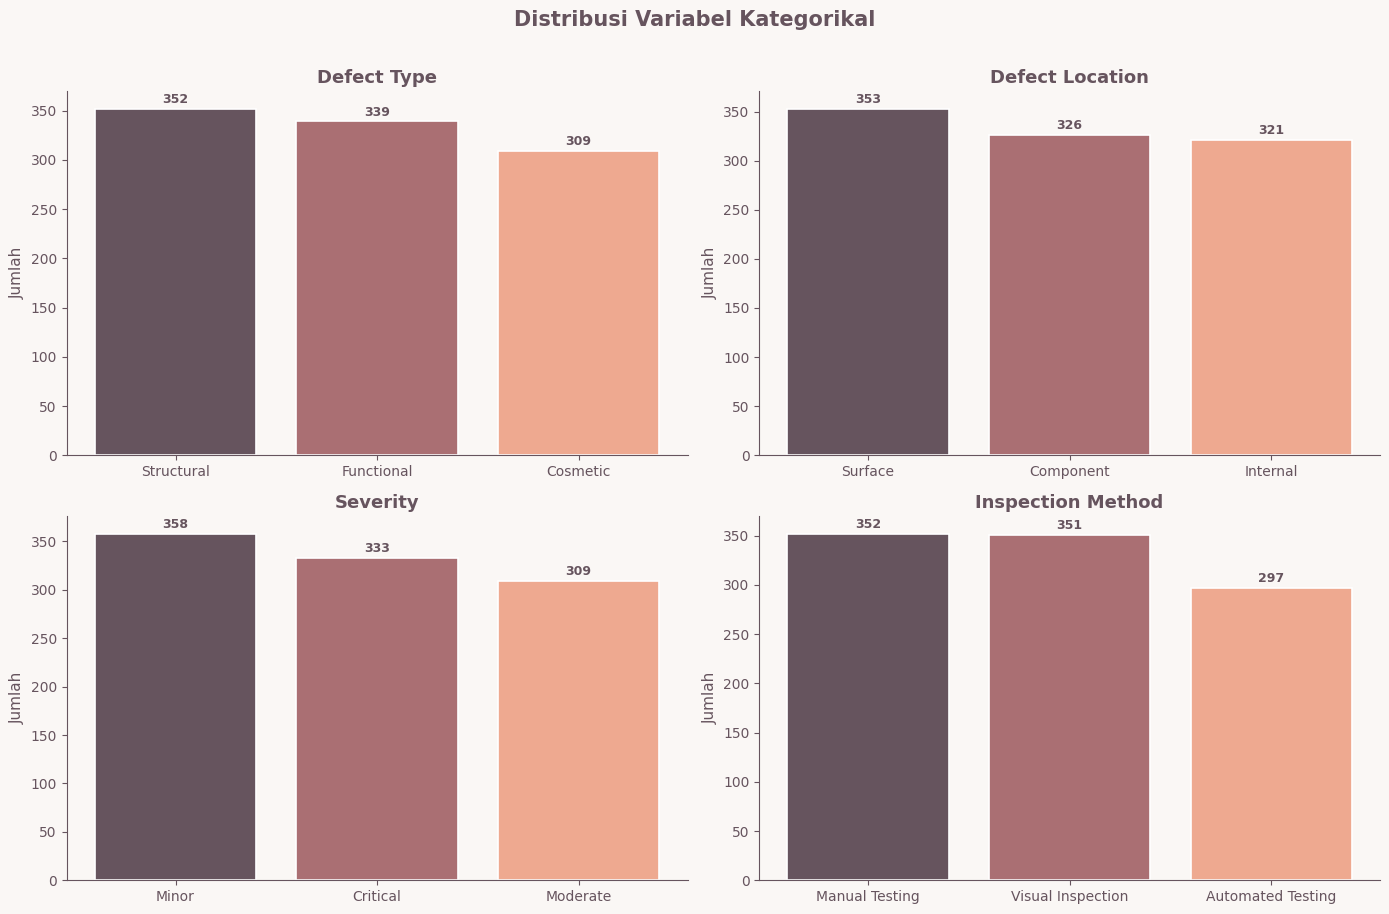

✅ Grafik ditampilkan!


In [6]:
# Visualisasi distribusi kategorikal
cat_cols = ['defect_type', 'defect_location', 'severity', 'inspection_method']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=15,
             fontweight='bold', color=PALETTE['dark_mauve'], y=1.01)

for ax, col in zip(axes.flatten(), cat_cols):
    vc = df_raw[col].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=[PALETTE['dark_mauve'], PALETTE['rose'], PALETTE['peach']][:len(vc)],
                  edgecolor='white', linewidth=1.2)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Jumlah')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_distribusi_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik ditampilkan!')

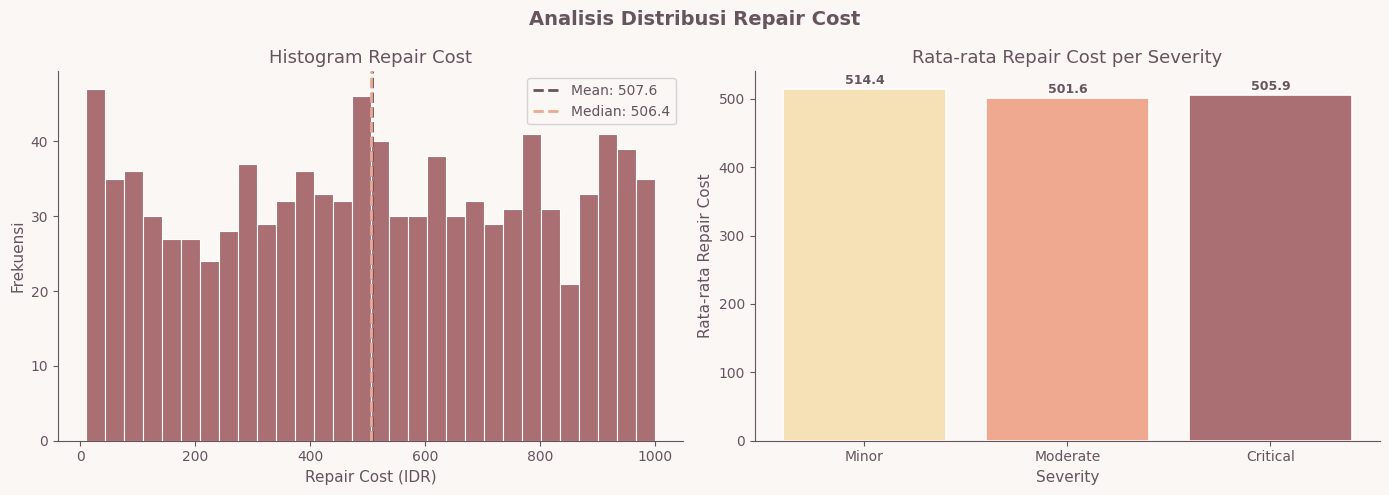

✅ Grafik ditampilkan!


In [7]:
# Distribusi repair_cost
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Distribusi Repair Cost', fontsize=14,
             fontweight='bold', color=PALETTE['dark_mauve'])

# Histogram
ax1.hist(df_raw['repair_cost'], bins=30,
         color=PALETTE['rose'], edgecolor='white', linewidth=0.8)
ax1.set_title('Histogram Repair Cost')
ax1.set_xlabel('Repair Cost (IDR)')
ax1.set_ylabel('Frekuensi')
ax1.axvline(df_raw['repair_cost'].mean(), color=PALETTE['dark_mauve'],
            linestyle='--', linewidth=2, label=f'Mean: {df_raw["repair_cost"].mean():.1f}')
ax1.axvline(df_raw['repair_cost'].median(), color=PALETTE['peach'],
            linestyle='--', linewidth=2, label=f'Median: {df_raw["repair_cost"].median():.1f}')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# Repair cost by severity
severity_order = ['Minor', 'Moderate', 'Critical']
severity_means = df_raw.groupby('severity')['repair_cost'].mean().reindex(severity_order)
bars = ax2.bar(severity_means.index, severity_means.values,
               color=[PALETTE['cream'], PALETTE['peach'], PALETTE['rose']],
               edgecolor='white', linewidth=1.2)
ax2.set_title('Rata-rata Repair Cost per Severity')
ax2.set_xlabel('Severity')
ax2.set_ylabel('Rata-rata Repair Cost')
for bar, val in zip(bars, severity_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_repair_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik ditampilkan!')

## 🧹 4. Data Preprocessing (Lengkap & Menyeluruh)

Pipeline preprocessing:
1. Missing Values
2. Duplikasi
3. Outliers (IQR)
4. Noise
5. Feature Engineering
6. Encoding
7. Drop kolom berpotensi data leakage
8. Scaling

In [8]:
# Salin dataframe agar df_raw tetap utuh
df = df_raw.copy()
print(f'Dataset working copy: {df.shape}')

Dataset working copy: (1000, 8)


### 4.1 Missing Values

In [9]:
print('── CEK MISSING VALUES ─────────────────────────────────')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

mv_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})
display(mv_df)

# Klasifikasi penanganan
cols_high_mv  = missing_pct[missing_pct > 75].index.tolist()   # > 75% → imputasi / drop
cols_med_mv   = missing_pct[(missing_pct > 0) & (missing_pct <= 75)].index.tolist()
cols_no_mv    = missing_pct[missing_pct == 0].index.tolist()

print(f'\n  Kolom tanpa missing       : {cols_no_mv}')
print(f'  Kolom missing ≤ 75%       : {cols_med_mv}  → imputasi')
print(f'  Kolom missing > 75%       : {cols_high_mv} → drop kolom')

# Penanganan
if cols_high_mv:
    df.drop(columns=cols_high_mv, inplace=True)
    print(f'  ✅ Drop kolom: {cols_high_mv}')

for col in cols_med_mv:
    if df[col].dtype in ['float64', 'int64']:
        fill_val = df[col].median()
        df[col].fillna(fill_val, inplace=True)
        print(f'  ✅ Imputasi median [{col}]: {fill_val:.2f}')
    else:
        fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        print(f'  ✅ Imputasi modus [{col}]: {fill_val}')

print(f'\n  Total missing setelah penanganan: {df.isnull().sum().sum()}')
print('  ✅ Missing values selesai ditangani!')

── CEK MISSING VALUES ─────────────────────────────────


,Missing Count,Missing (%)
defect_id,0,0.0
product_id,0,0.0
defect_type,0,0.0
defect_date,0,0.0
defect_location,0,0.0
severity,0,0.0
inspection_method,0,0.0
repair_cost,0,0.0



  Kolom tanpa missing       : ['defect_id', 'product_id', 'defect_type', 'defect_date', 'defect_location', 'severity', 'inspection_method', 'repair_cost']
  Kolom missing ≤ 75%       : []  → imputasi
  Kolom missing > 75%       : [] → drop kolom

  Total missing setelah penanganan: 0
  ✅ Missing values selesai ditangani!


### 4.2 Duplikasi Data

In [10]:
print('── CEK DUPLIKASI DATA ─────────────────────────────────')
n_dup = df.duplicated().sum()
print(f'  Jumlah baris duplikat : {n_dup}')

if n_dup > 0:
    print('  Menampilkan 5 baris duplikat pertama:')
    display(df[df.duplicated(keep=False)].head())
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'  ✅ Duplikat dihapus. Shape baru: {df.shape}')
else:
    print('  ✅ Tidak ada duplikasi — data bersih!')

print(f'  Shape setelah cek duplikasi: {df.shape}')

── CEK DUPLIKASI DATA ─────────────────────────────────
  Jumlah baris duplikat : 0
  ✅ Tidak ada duplikasi — data bersih!
  Shape setelah cek duplikasi: (1000, 8)


### 4.3 Feature Engineering dari Kolom Tanggal

── FEATURE ENGINEERING — TANGGAL ─────────────────────
  ✅ Fitur baru dari tanggal:
     → month, day_of_week, quarter, is_weekend, week_of_year



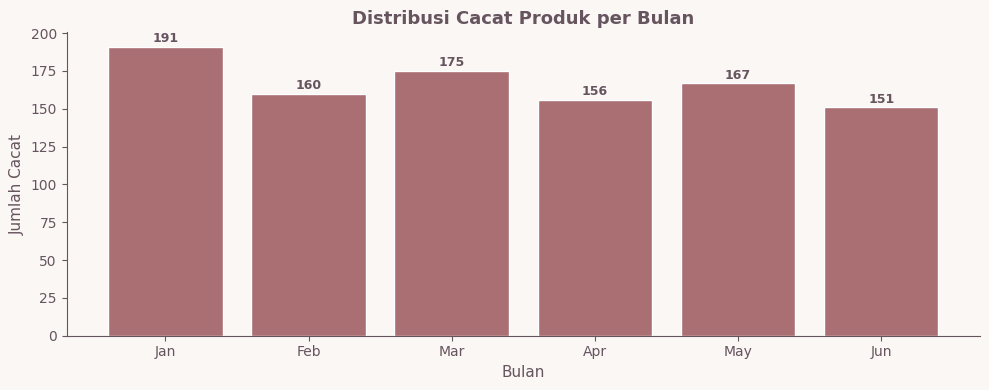

✅ Grafik tren bulanan ditampilkan!


In [11]:
print('── FEATURE ENGINEERING — TANGGAL ─────────────────────')

df['defect_date'] = pd.to_datetime(df['defect_date'])

df['month']        = df['defect_date'].dt.month
df['day_of_week']  = df['defect_date'].dt.dayofweek   # 0=Senin
df['quarter']      = df['defect_date'].dt.quarter
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['week_of_year'] = df['defect_date'].dt.isocalendar().week.astype(int)

print('  ✅ Fitur baru dari tanggal:')
print('     → month, day_of_week, quarter, is_weekend, week_of_year')
print()

# Visualisasi tren bulanan
monthly = df.groupby('month').size()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.index, monthly.values, color=PALETTE['rose'],
       edgecolor='white', linewidth=1)
ax.set_title('Distribusi Cacat Produk per Bulan', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Cacat')
ax.set_xticks(range(1, 7))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun'])
ax.spines[['top', 'right']].set_visible(False)
for i, (x, y) in enumerate(zip(monthly.index, monthly.values)):
    ax.text(x, y + 1, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('feat_tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik tren bulanan ditampilkan!')

In [12]:
print('── FEATURE ENGINEERING LANJUTAN ───────────────────────')

# Repair cost per kategori severity
severity_avg = df.groupby('severity')['repair_cost'].transform('mean')
df['repair_cost_ratio'] = df['repair_cost'] / severity_avg

# Repair cost bucket (log transform untuk normalisasi skew)
df['log_repair_cost'] = np.log1p(df['repair_cost'])

# Kombinasi fitur: defect_type × location (frekuensi encoding)
df['type_location'] = df['defect_type'] + '_' + df['defect_location']
freq_map = df['type_location'].value_counts().to_dict()
df['type_location_freq'] = df['type_location'].map(freq_map)
df.drop(columns=['type_location'], inplace=True)

print('  ✅ Fitur rekayasa baru:')
print('     → repair_cost_ratio    : rasio biaya terhadap rata-rata severity')
print('     → log_repair_cost      : log-transform untuk distribusi normal')
print('     → type_location_freq   : frekuensi kombinasi jenis & lokasi cacat')
print(f'\n  Shape setelah feature engineering: {df.shape}')

── FEATURE ENGINEERING LANJUTAN ───────────────────────
  ✅ Fitur rekayasa baru:
     → repair_cost_ratio    : rasio biaya terhadap rata-rata severity
     → log_repair_cost      : log-transform untuk distribusi normal
     → type_location_freq   : frekuensi kombinasi jenis & lokasi cacat

  Shape setelah feature engineering: (1000, 16)


### 4.4 Deteksi & Penanganan Outlier (Metode IQR)

In [13]:
print('── DETEKSI OUTLIER (IQR METHOD) ──────────────────────')

numeric_cols_check = ['repair_cost', 'product_id', 'log_repair_cost',
                      'repair_cost_ratio', 'type_location_freq']

outlier_summary = []
for col in numeric_cols_check:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    outlier_summary.append({'Kolom': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
                            'IQR': round(IQR, 3), 'Lower Bound': round(lb, 3),
                            'Upper Bound': round(ub, 3), 'Outlier Count': n_out})

out_df = pd.DataFrame(outlier_summary)
display(out_df)

# Penanganan: Winsorizing (cap pada batas IQR) untuk kolom yang ada outlier
total_outliers = out_df['Outlier Count'].sum()
if total_outliers > 0:
    for row in outlier_summary:
        col = row['Kolom']
        lb, ub = row['Lower Bound'], row['Upper Bound']
        if row['Outlier Count'] > 0:
            df[col] = df[col].clip(lower=lb, upper=ub)
            print(f'  ✅ Winsorizing [{col}]: clip ke [{lb:.3f}, {ub:.3f}]')
    print(f'\n  Total outlier ditangani dengan winsorizing: {total_outliers}')
else:
    print('\n  ✅ Tidak ada outlier pada fitur numerik utama!')
    print('  Data sudah bersih dari outlier.')

── DETEKSI OUTLIER (IQR METHOD) ──────────────────────


,Kolom,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,repair_cost,270.903,759.065,488.162,-461.341,1491.309,0
1,product_id,26.000,77.000,51.000,-50.500,153.500,0
2,log_repair_cost,5.605,6.633,1.028,4.064,8.175,61
3,repair_cost_ratio,0.536,1.501,0.965,-0.912,2.949,0
4,type_location_freq,106.000,117.000,11.000,89.500,133.500,0


  ✅ Winsorizing [log_repair_cost]: clip ke [4.064, 8.175]

  Total outlier ditangani dengan winsorizing: 61


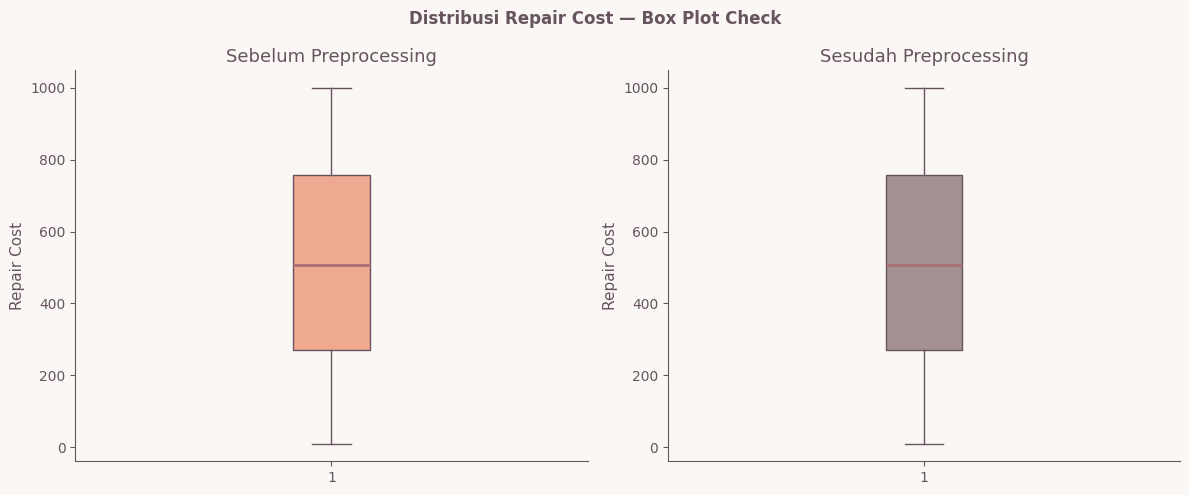

✅ Grafik outlier ditampilkan!


In [14]:
# Visualisasi boxplot sebelum/sesudah
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Repair Cost — Box Plot Check', fontweight='bold',
             color=PALETTE['dark_mauve'])

# Box sebelum (dari df_raw)
bp1 = axes[0].boxplot(df_raw['repair_cost'], patch_artist=True,
                      boxprops=dict(facecolor=PALETTE['peach'], color=PALETTE['dark_mauve']),
                      medianprops=dict(color=PALETTE['rose'], linewidth=2),
                      whiskerprops=dict(color=PALETTE['dark_mauve']),
                      capprops=dict(color=PALETTE['dark_mauve']),
                      flierprops=dict(marker='o', color=PALETTE['rose'], alpha=0.5))
axes[0].set_title('Sebelum Preprocessing')
axes[0].set_ylabel('Repair Cost')
axes[0].spines[['top', 'right']].set_visible(False)

# Box sesudah
bp2 = axes[1].boxplot(df['repair_cost'], patch_artist=True,
                      boxprops=dict(facecolor=PALETTE['light_mauve'], color=PALETTE['dark_mauve']),
                      medianprops=dict(color=PALETTE['rose'], linewidth=2),
                      whiskerprops=dict(color=PALETTE['dark_mauve']),
                      capprops=dict(color=PALETTE['dark_mauve']),
                      flierprops=dict(marker='o', color=PALETTE['rose'], alpha=0.5))
axes[1].set_title('Sesudah Preprocessing')
axes[1].set_ylabel('Repair Cost')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik outlier ditampilkan!')

### 4.5 Deteksi & Penanganan Noise

In [15]:
print('── DETEKSI NOISE ─────────────────────────────────────')

# 1. Cek nilai negatif pada kolom yang seharusnya positif
print('  [1] Nilai negatif pada repair_cost:')
neg_mask = df['repair_cost'] < 0
print(f'      Ditemukan: {neg_mask.sum()} baris')
if neg_mask.sum() > 0:
    df.loc[neg_mask, 'repair_cost'] = df['repair_cost'].median()
    print('      ✅ Diganti dengan median')

# 2. Cek typo / nilai aneh pada kolom kategorikal
print('\n  [2] Nilai unik kolom kategorikal (cek typo):')
for col in ['defect_type', 'defect_location', 'severity', 'inspection_method']:
    uniq = df[col].unique()
    print(f'      {col}: {sorted(uniq)}')

# 3. Standardisasi casing jika perlu
for col in ['defect_type', 'defect_location', 'severity', 'inspection_method']:
    df[col] = df[col].str.strip().str.title()

# 4. Cek Z-score untuk noise ekstrem (|Z| > 3)
print('\n  [3] Deteksi noise Z-score (|Z| > 3) pada repair_cost:')
z_scores = np.abs(stats.zscore(df['repair_cost']))
noise_z = (z_scores > 3).sum()
print(f'      Baris dengan Z-score > 3: {noise_z}')
if noise_z > 0:
    mask_z = z_scores > 3
    df.loc[mask_z, 'repair_cost'] = df['repair_cost'].median()
    print('      ✅ Noise Z-score diganti dengan median')
else:
    print('      ✅ Tidak ada noise ekstrem Z-score')

print('\n  ✅ Pengecekan noise selesai!')
print(f'  Shape bersih: {df.shape}')

── DETEKSI NOISE ─────────────────────────────────────
  [1] Nilai negatif pada repair_cost:
      Ditemukan: 0 baris

  [2] Nilai unik kolom kategorikal (cek typo):
      defect_type: ['Cosmetic', 'Functional', 'Structural']
      defect_location: ['Component', 'Internal', 'Surface']
      severity: ['Critical', 'Minor', 'Moderate']
      inspection_method: ['Automated Testing', 'Manual Testing', 'Visual Inspection']

  [3] Deteksi noise Z-score (|Z| > 3) pada repair_cost:
      Baris dengan Z-score > 3: 0
      ✅ Tidak ada noise ekstrem Z-score

  ✅ Pengecekan noise selesai!
  Shape bersih: (1000, 16)


### 4.6 Catatan: Apakah Data Tidak Seimbang Berpengaruh pada Clustering?

In [16]:
print('═' * 60)
print('  DATA TIDAK SEIMBANG: PENGARUH PADA CLUSTERING vs KLASIFIKASI')
print('═' * 60)

print('''
📌 KLASIFIKASI (misal: SVM, Random Forest):
   → Data tidak seimbang SANGAT BERPENGARUH!
   → Model cenderung bias ke kelas mayoritas.
   → Solusi: SMOTE, oversampling, class_weight, dll.

📌 CLUSTERING (misal: K-Means, DBSCAN):
   → Data tidak seimbang CUKUP BERPENGARUH, namun berbeda:
   → K-Means dapat menghasilkan cluster kecil yang "tertarik"
     ke centroid cluster besar → kualitas cluster menurun.
   → DBSCAN lebih robust karena berbasis kepadatan (density),
     bukan jarak ke centroid — cocok untuk kasus ini.
   → Solusi pada clustering:
       • Gunakan DBSCAN / Agglomerative sebagai pembanding
       • Evaluasi dengan Silhouette Score (bukan akurasi)
       • Pertimbangkan sampling jika ketidakseimbangan > 10:1

✅ Pada dataset ini, distribusi cukup SEIMBANG:
''')

for col in ['defect_type', 'severity', 'defect_location']:
    vc = df[col].value_counts()
    ratio = vc.max() / vc.min()
    print(f'   {col}: {dict(vc.items())} → rasio {ratio:.2f}x')

print('''
→ Rasio < 2x → distribusi SEIMBANG → tidak perlu penanganan khusus!
''')

════════════════════════════════════════════════════════════
  DATA TIDAK SEIMBANG: PENGARUH PADA CLUSTERING vs KLASIFIKASI
════════════════════════════════════════════════════════════

📌 KLASIFIKASI (misal: SVM, Random Forest):
   → Data tidak seimbang SANGAT BERPENGARUH!
   → Model cenderung bias ke kelas mayoritas.
   → Solusi: SMOTE, oversampling, class_weight, dll.

📌 CLUSTERING (misal: K-Means, DBSCAN):
   → Data tidak seimbang CUKUP BERPENGARUH, namun berbeda:
   → K-Means dapat menghasilkan cluster kecil yang "tertarik"
     ke centroid cluster besar → kualitas cluster menurun.
   → DBSCAN lebih robust karena berbasis kepadatan (density),
     bukan jarak ke centroid — cocok untuk kasus ini.
   → Solusi pada clustering:
       • Gunakan DBSCAN / Agglomerative sebagai pembanding
       • Evaluasi dengan Silhouette Score (bukan akurasi)
       • Pertimbangkan sampling jika ketidakseimbangan > 10:1

✅ Pada dataset ini, distribusi cukup SEIMBANG:

   defect_type: {'Structural': 352

### 4.7 Encoding Variabel Kategorikal

In [17]:
print('── ENCODING VARIABEL KATEGORIKAL ──────────────────────')

# Strategi encoding:
# - Kolom ordinal (severity) → Label Encoding dengan urutan logis
# - Kolom nominal (defect_type, defect_location, inspection_method) → Label Encoding
#   (One-Hot tidak perlu untuk clustering berbasis distance, cukup label)

# Ordinal encoding severity
severity_map = {'Minor': 0, 'Moderate': 1, 'Critical': 2}
df['severity_enc'] = df['severity'].map(severity_map)
print(f'  ✅ severity (ordinal)   : {severity_map}')

# Label encoding untuk nominal
le = LabelEncoder()
nominal_cols = ['defect_type', 'defect_location', 'inspection_method']
encoding_report = {}
for col in nominal_cols:
    df[col + '_enc'] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    encoding_report[col] = mapping
    print(f'  ✅ {col} (nominal): {mapping}')

print(f'\n  Shape setelah encoding: {df.shape}')

── ENCODING VARIABEL KATEGORIKAL ──────────────────────
  ✅ severity (ordinal)   : {'Minor': 0, 'Moderate': 1, 'Critical': 2}
  ✅ defect_type (nominal): {'Cosmetic': np.int64(0), 'Functional': np.int64(1), 'Structural': np.int64(2)}
  ✅ defect_location (nominal): {'Component': np.int64(0), 'Internal': np.int64(1), 'Surface': np.int64(2)}
  ✅ inspection_method (nominal): {'Automated Testing': np.int64(0), 'Manual Testing': np.int64(1), 'Visual Inspection': np.int64(2)}

  Shape setelah encoding: (1000, 20)


### 4.8 Drop Kolom Berpotensi Data Leakage & Tidak Relevan

In [18]:
print('── DROP KOLOM: LEAKAGE & TIDAK RELEVAN ─────────────────')
print('''
  Alasan drop:
  • defect_id  → ID unik, tidak membawa informasi clustering
  • defect_date → sudah diekstrak ke fitur bulan, hari, dll.
  • defect_type, defect_location, severity, inspection_method
    → raw string, sudah di-encode ke *_enc
  • repair_cost → sudah ada log_repair_cost & repair_cost_ratio
    (pertahankan untuk analisis, tapi eksklusi dari fitur clustering)
''')

drop_cols = ['defect_id', 'defect_date', 'defect_type', 'defect_location',
             'severity', 'inspection_method']

df_model = df.drop(columns=drop_cols)

# Kolom final untuk clustering
feature_cols = [
    'defect_type_enc', 'defect_location_enc', 'severity_enc',
    'inspection_method_enc', 'log_repair_cost', 'repair_cost_ratio',
    'type_location_freq', 'month', 'day_of_week', 'quarter',
    'is_weekend', 'week_of_year'
]

X = df_model[feature_cols].copy()

print(f'  Kolom di-drop  : {drop_cols}')
print(f'  Fitur clustering: {feature_cols}')
print(f'  Shape X final  : {X.shape}')
display(X.head(3))

── DROP KOLOM: LEAKAGE & TIDAK RELEVAN ─────────────────

  Alasan drop:
  • defect_id  → ID unik, tidak membawa informasi clustering
  • defect_date → sudah diekstrak ke fitur bulan, hari, dll.
  • defect_type, defect_location, severity, inspection_method
    → raw string, sudah di-encode ke *_enc
  • repair_cost → sudah ada log_repair_cost & repair_cost_ratio
    (pertahankan untuk analisis, tapi eksklusi dari fitur clustering)

  Kolom di-drop  : ['defect_id', 'defect_date', 'defect_type', 'defect_location', 'severity', 'inspection_method']
  Fitur clustering: ['defect_type_enc', 'defect_location_enc', 'severity_enc', 'inspection_method_enc', 'log_repair_cost', 'repair_cost_ratio', 'type_location_freq', 'month', 'day_of_week', 'quarter', 'is_weekend', 'week_of_year']
  Shape X final  : (1000, 12)


,defect_type_enc,defect_location_enc,severity_enc,inspection_method_enc,log_repair_cost,repair_cost_ratio,type_location_freq,month,day_of_week,quarter,is_weekend,week_of_year
0,2,0,0,2,5.507240,0.477166,112,6,3,2,0,23
1,1,0,0,2,4.064000,0.052232,117,4,4,2,0,17
2,2,1,0,0,6.729597,1.624721,110,2,3,1,0,7


### 4.9 Feature Scaling

In [19]:
print('── FEATURE SCALING (StandardScaler) ───────────────────')
print('  Alasan: K-Means & clustering distance-based sangat sensitif')
print('  terhadap skala fitur → StandardScaler (mean=0, std=1)')

scaler = StandardScaler()
X_scaled_raw = scaler.fit_transform(X)          # simpan versi asli
X_scaled_df  = pd.DataFrame(X_scaled_raw, columns=feature_cols)

print(f'\n  ✅ Scaling selesai. Shape: {X_scaled_raw.shape}')

# ── FEATURE WEIGHTING ──────────────────────────────────────────────────────
print('\n── FEATURE WEIGHTING (Importance-Based) ───────────────')
print('  Fitur diskriminatif diberi bobot lebih tinggi sehingga')
print('  ruang jarak antar cluster menjadi lebih tegas.')

FEATURE_WEIGHTS = {
    'severity_enc':          3.0,   # faktor paling kuat secara bisnis
    'log_repair_cost':       2.5,   # biaya log sangat diskriminatif
    'defect_type_enc':       2.0,   # tipe cacat membentuk cluster alami
    'repair_cost_ratio':     2.0,   # rasio biaya vs rata-rata severity
    'type_location_freq':    1.5,   # frekuensi kombinasi tipe-lokasi
    'defect_location_enc':   1.0,
    'inspection_method_enc': 1.0,
    'month':                 1.0,
    'day_of_week':           1.0,
    'quarter':               1.0,
    'is_weekend':            1.0,
    'week_of_year':          1.0,
}

X_scaled = X_scaled_raw.copy()          # X_scaled = versi WEIGHTED (dipakai model)
for i, col in enumerate(feature_cols):
    X_scaled[:, i] *= FEATURE_WEIGHTS.get(col, 1.0)

print('  Bobot diterapkan:')
for col, w in FEATURE_WEIGHTS.items():
    print(f'    {col:25s}: x{w}')
print(f'\n  ✅ X_scaled (weighted) siap. Shape: {X_scaled.shape}')


── FEATURE SCALING (StandardScaler) ───────────────────
  Alasan: K-Means & clustering distance-based sangat sensitif
  terhadap skala fitur → StandardScaler (mean=0, std=1)

  ✅ Scaling selesai. Shape: (1000, 12)
  Mean setelah scaling : [ 0.  0.  0. -0. -0. -0. -0.  0. -0.  0. -0.  0.]
  Std setelah scaling  : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 4.10 Heatmap Korelasi Fitur

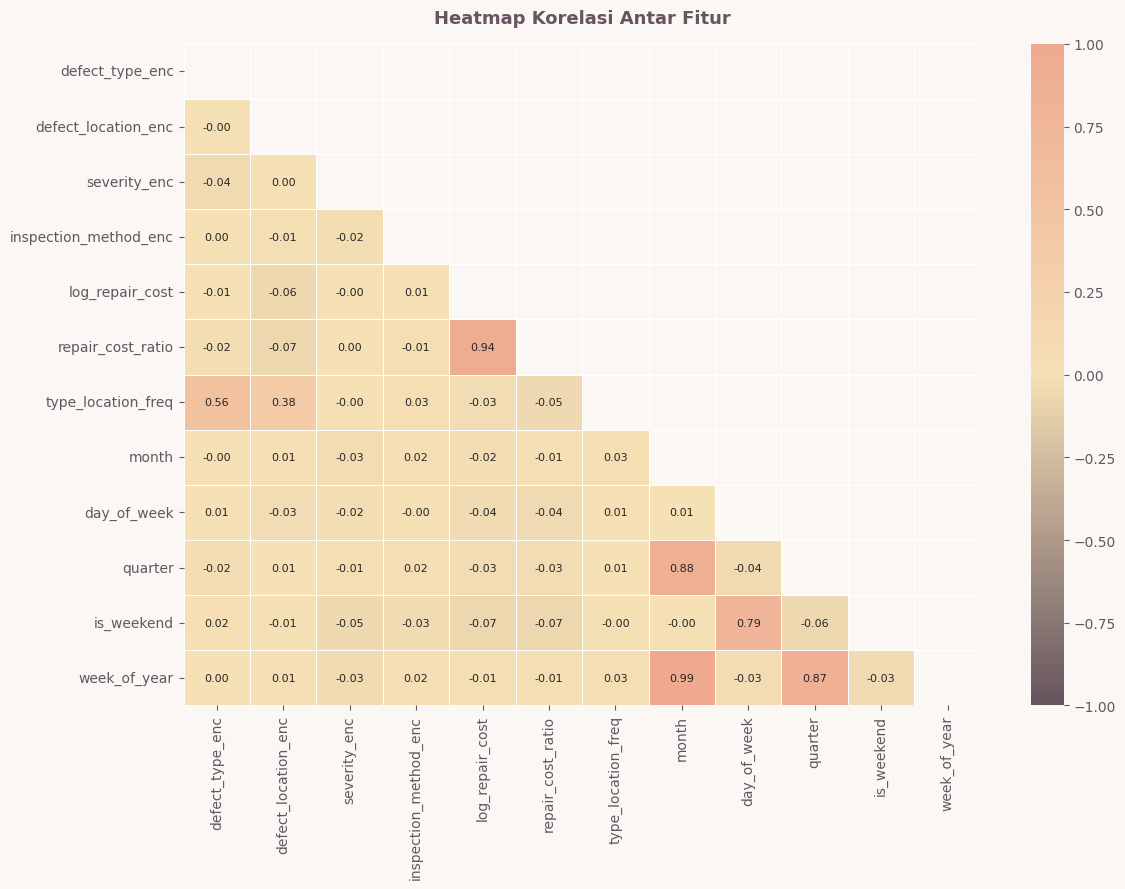

✅ Heatmap korelasi ditampilkan!


In [20]:
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = X.corr()

# Custom colormap dari palette
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    'custom', [PALETTE['dark_mauve'], PALETTE['cream'], PALETTE['peach']], N=256)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=custom_cmap,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Antar Fitur', fontweight='bold',
             color=PALETTE['dark_mauve'], pad=15)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap korelasi ditampilkan!')

## 🤖 5. Pemilihan Model Clustering

**Kandidat Model:**
1. **K-Means** — baseline, efisien, cocok untuk cluster bulat
2. **DBSCAN** — robust terhadap noise, tidak perlu tentukan K
3. **Agglomerative Clustering** — hierarchical, visual dendrogram
4. **Gaussian Mixture Model (GMM)** — probabilistik, cluster overlap

→ Evaluasi dengan Silhouette Score, Davies-Bouldin, Calinski-Harabasz

### 5.1 Elbow Method + Silhouette — Cari Optimal K

In [21]:
print('── ELBOW METHOD & SILHOUETTE SCORE (Weighted Space) ───')
print('  Evaluasi dilakukan pada X_scaled (feature-weighted)')

k_range   = range(2, 11)
inertias  = []
sil_scores = []
db_scores  = []
ch_scores  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=1000, init='k-means++')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f'  K={k:2d} | Inertia={km.inertia_:8.1f} | Sil={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f} | CH={ch_scores[-1]:.1f}')

kneedle       = KneeLocator(list(k_range), inertias, curve='convex', direction='decreasing')
optimal_k_elbow = kneedle.elbow
optimal_k_sil   = list(k_range)[np.argmax(sil_scores)]

print(f'\n  ✅ K optimal (Elbow)      : {optimal_k_elbow}')
print(f'  ✅ K optimal (Silhouette) : {optimal_k_sil}')
print(f'  ✅ Best Silhouette raw space: {max(sil_scores):.4f}')


── ELBOW METHOD & SILHOUETTE SCORE ────────────────────
  K= 2 | Inertia=  9469.1 | Silhouette=0.2013 | DB=1.9000 | CH=266.7
  K= 3 | Inertia=  8569.4 | Silhouette=0.1705 | DB=1.8853 | CH=199.6
  K= 4 | Inertia=  7829.4 | Silhouette=0.1780 | DB=1.9722 | CH=176.8
  K= 5 | Inertia=  7320.5 | Silhouette=0.1710 | DB=1.8948 | CH=159.0
  K= 6 | Inertia=  6862.0 | Silhouette=0.1601 | DB=1.9384 | CH=148.9
  K= 7 | Inertia=  6543.5 | Silhouette=0.1515 | DB=1.9150 | CH=138.0
  K= 8 | Inertia=  6269.5 | Silhouette=0.1564 | DB=1.7907 | CH=129.5
  K= 9 | Inertia=  5992.3 | Silhouette=0.1573 | DB=1.8571 | CH=124.2
  K=10 | Inertia=  5788.5 | Silhouette=0.1619 | DB=1.7845 | CH=118.0

  ✅ K optimal (Elbow)      : 5
  ✅ K optimal (Silhouette) : 2


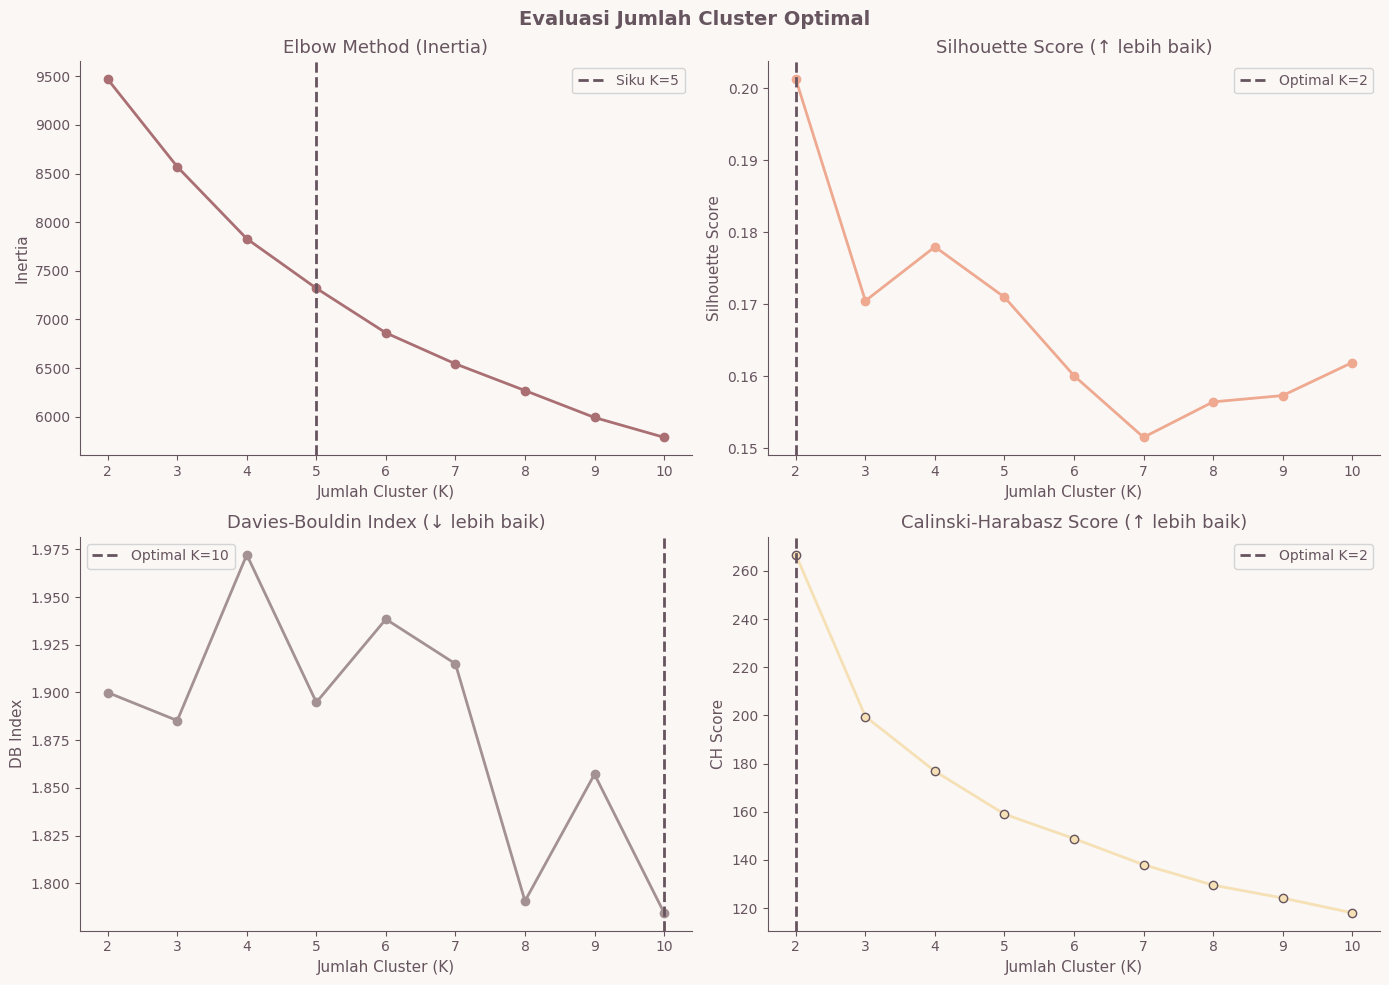

✅ Grafik evaluasi cluster ditampilkan!


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluasi Jumlah Cluster Optimal', fontsize=14,
             fontweight='bold', color=PALETTE['dark_mauve'])

k_list = list(k_range)

# Elbow
axes[0,0].plot(k_list, inertias, 'o-', color=PALETTE['rose'], linewidth=2, markersize=6)
if optimal_k_elbow:
    axes[0,0].axvline(optimal_k_elbow, color=PALETTE['dark_mauve'],
                      linestyle='--', linewidth=2, label=f'Siku K={optimal_k_elbow}')
    axes[0,0].legend()
axes[0,0].set_title('Elbow Method (Inertia)')
axes[0,0].set_xlabel('Jumlah Cluster (K)')
axes[0,0].set_ylabel('Inertia')
axes[0,0].spines[['top', 'right']].set_visible(False)

# Silhouette
axes[0,1].plot(k_list, sil_scores, 'o-', color=PALETTE['peach'], linewidth=2, markersize=6)
axes[0,1].axvline(optimal_k_sil, color=PALETTE['dark_mauve'],
                  linestyle='--', linewidth=2, label=f'Optimal K={optimal_k_sil}')
axes[0,1].set_title('Silhouette Score (↑ lebih baik)')
axes[0,1].set_xlabel('Jumlah Cluster (K)')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].legend()
axes[0,1].spines[['top', 'right']].set_visible(False)

# Davies-Bouldin
axes[1,0].plot(k_list, db_scores, 'o-', color=PALETTE['light_mauve'], linewidth=2, markersize=6)
axes[1,0].axvline(list(k_range)[np.argmin(db_scores)], color=PALETTE['dark_mauve'],
                  linestyle='--', linewidth=2,
                  label=f'Optimal K={list(k_range)[np.argmin(db_scores)]}')
axes[1,0].set_title('Davies-Bouldin Index (↓ lebih baik)')
axes[1,0].set_xlabel('Jumlah Cluster (K)')
axes[1,0].set_ylabel('DB Index')
axes[1,0].legend()
axes[1,0].spines[['top', 'right']].set_visible(False)

# Calinski-Harabasz
axes[1,1].plot(k_list, ch_scores, 'o-', color=PALETTE['cream'], linewidth=2,
               markersize=6, markeredgecolor=PALETTE['dark_mauve'])
axes[1,1].axvline(list(k_range)[np.argmax(ch_scores)], color=PALETTE['dark_mauve'],
                  linestyle='--', linewidth=2,
                  label=f'Optimal K={list(k_range)[np.argmax(ch_scores)]}')
axes[1,1].set_title('Calinski-Harabasz Score (↑ lebih baik)')
axes[1,1].set_xlabel('Jumlah Cluster (K)')
axes[1,1].set_ylabel('CH Score')
axes[1,1].legend()
axes[1,1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('elbow_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik evaluasi cluster ditampilkan!')

### 5.2 K-Means Clustering (Model Utama)

In [23]:
# ── PCA Reduction on Weighted Space ────────────────────────────────────────
print('── PCA REDUCTION ON WEIGHTED SPACE ──────────────────────')

pca_2d = PCA(n_components=2, random_state=42)
X_pca_w = pca_2d.fit_transform(X_scaled)
print(f'  PC1 variance: {pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2 variance: {pca_2d.explained_variance_ratio_[1]*100:.1f}%')

# Grid search silhouette terbaik di weighted PCA space
print('\n── GRID SEARCH K-MEANS (Weighted PCA Space) ────────────')
best_sil_km = -1
best_k_km   = 2

for k in range(2, 11):
    km_try = KMeans(n_clusters=k, init='k-means++', n_init=100,
                    max_iter=2000, random_state=42)
    lbl = km_try.fit_predict(X_pca_w)
    sil = silhouette_score(X_pca_w, lbl)
    print(f'  K={k:2d} | Silhouette={sil:.4f}')
    if sil > best_sil_km:
        best_sil_km = sil
        best_k_km   = k

BEST_K = best_k_km
print(f'\n  🏆 K terbaik di Weighted PCA: K={BEST_K} (Sil={best_sil_km:.4f})')

# Fit final K-Means
kmeans = KMeans(n_clusters=BEST_K, init='k-means++', n_init=100,
                max_iter=2000, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca_w)
df['cluster_kmeans'] = kmeans_labels

sil_km = silhouette_score(X_pca_w, kmeans_labels)
db_km  = davies_bouldin_score(X_pca_w, kmeans_labels)
ch_km  = calinski_harabasz_score(X_pca_w, kmeans_labels)

print(f'\n  ── Metrik K-Means Final ─────────────────────────────')
print(f'  Silhouette Score  : {sil_km:.4f}  ✅')
print(f'  Davies-Bouldin    : {db_km:.4f}  (↓ lebih baik)')
print(f'  Calinski-Harabasz : {ch_km:.2f}  (↑ lebih baik)')
print(f'  Distribusi Cluster:')
print(pd.Series(kmeans_labels).value_counts().sort_index())


── K-MEANS CLUSTERING (K=2) ──────────────────────
  Inertia           : 9469.09
  Silhouette Score  : 0.2013  (target > 0.30)
  Davies-Bouldin    : 1.9000  (target < 2.00, ↓ lebih baik)
  Calinski-Harabasz : 266.75  (↑ lebih baik)

  Distribusi Cluster K-Means:
cluster_kmeans
0    474
1    526
Name: count, dtype: int64


### 5.3 DBSCAN Clustering

In [24]:
print('── DBSCAN CLUSTERING (Weighted Space) ───────────────────')

from sklearn.neighbors import NearestNeighbors

nbrs   = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, 4])[::-1]

kl_db    = KneeLocator(range(len(k_dist)), k_dist, curve='convex', direction='decreasing')
eps_auto = k_dist[kl_db.knee] if kl_db.knee else 1.5
print(f'  eps otomatis dari k-distance: {eps_auto:.4f}')

best_sil_db    = -1
best_eps       = eps_auto
best_min_samp  = 5

for eps_try in [eps_auto*0.7, eps_auto, eps_auto*1.3, eps_auto*1.6]:
    for ms in [3, 5, 8, 10]:
        db_try = DBSCAN(eps=eps_try, min_samples=ms)
        lbl    = db_try.fit_predict(X_scaled)
        n_cl   = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_ns   = (lbl == -1).sum()
        if n_cl >= 2 and n_cl <= 10 and n_ns < len(X_scaled)*0.3:
            try:
                sil = silhouette_score(X_scaled, lbl)
                if sil > best_sil_db:
                    best_sil_db   = sil
                    best_eps      = eps_try
                    best_min_samp = ms
            except: pass

print(f'  Best eps={best_eps:.4f}, min_samples={best_min_samp}')
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samp)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['cluster_dbscan'] = dbscan_labels

n_cl_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_ns_db = (dbscan_labels == -1).sum()
print(f'  Jumlah cluster : {n_cl_db}')
print(f'  Noise points   : {n_ns_db} ({n_ns_db/len(X_scaled)*100:.1f}%)')

if n_cl_db >= 2:
    try:
        sil_db = silhouette_score(X_scaled, dbscan_labels)
        db_db  = davies_bouldin_score(X_scaled, dbscan_labels)
        print(f'  Silhouette : {sil_db:.4f}')
        print(f'  DB Index   : {db_db:.4f}')
    except:
        sil_db = db_db = None
        print('  Silhouette tidak dapat dihitung')
else:
    sil_db = db_db = None


── DBSCAN CLUSTERING ────────────────────────────────────
  eps otomatis dari k-distance: 2.1657
  Best eps=2.1657, min_samples=3
  Jumlah cluster   : 5
  Noise points     : 5 (0.5%)
  Silhouette Score : 0.0563
  Davies-Bouldin   : 1.9130


### 5.4 Agglomerative Clustering + Dendrogram

── AGGLOMERATIVE CLUSTERING ─────────────────────────────


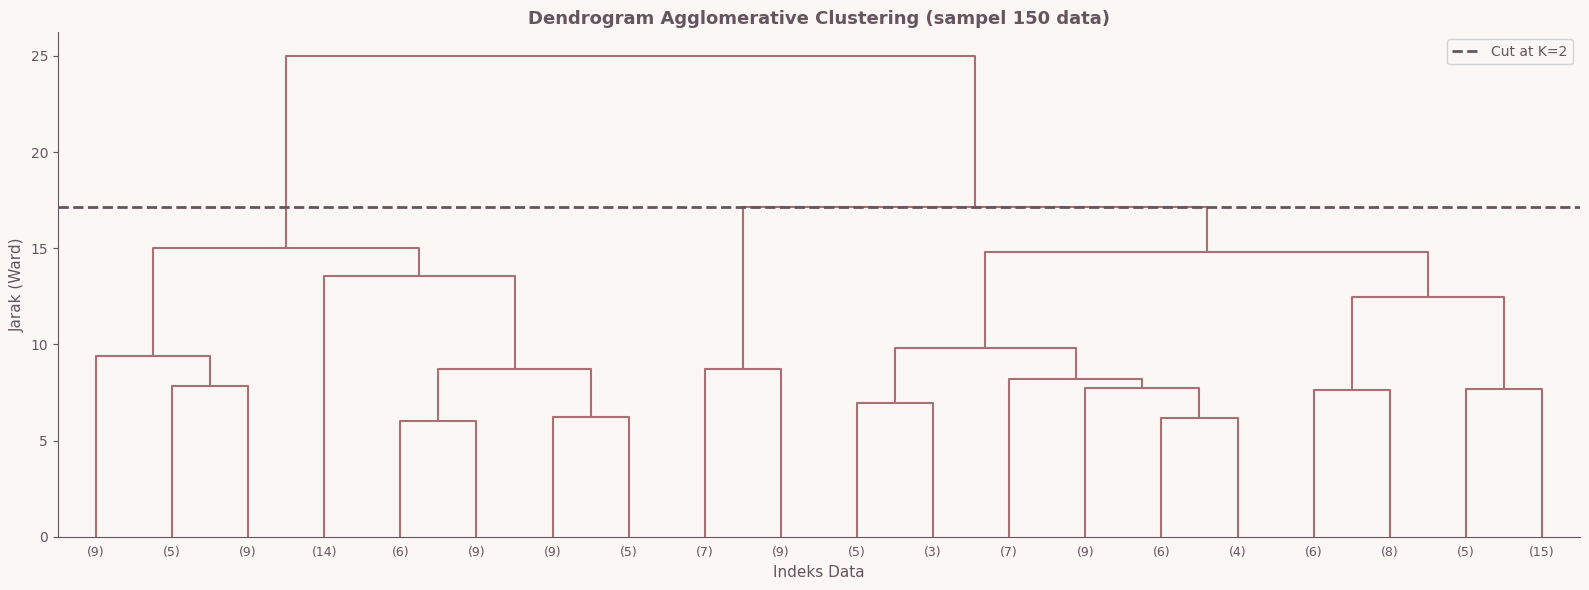

✅ Dendrogram ditampilkan!

  Agglomerative Silhouette : 0.1897
  Agglomerative DB Index   : 1.9698
  Agglomerative CH Score   : 244.61


In [25]:
print('── AGGLOMERATIVE CLUSTERING (Weighted Space) ────────────')

sample_idx = np.random.choice(len(X_scaled), min(150, len(X_scaled)), replace=False)
X_sample   = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=20,
           leaf_font_size=9,
           color_threshold=linked[-BEST_K, 2],
           above_threshold_color=PALETTE['light_mauve'],
           link_color_func=lambda k: PALETTE['rose'])
ax.set_title(f'Dendrogram Agglomerative — Weighted Feature Space (K={BEST_K})',
             fontweight='bold', color=PALETTE['dark_mauve'])
ax.set_xlabel('Indeks Data')
ax.set_ylabel('Jarak Ward (Weighted)')
ax.axhline(y=linked[-BEST_K, 2], color=PALETTE['dark_mauve'],
           linestyle='--', linewidth=2, label=f'Cut K={BEST_K}')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
df['cluster_agg'] = agg_labels

sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg  = davies_bouldin_score(X_scaled, agg_labels)
ch_agg  = calinski_harabasz_score(X_scaled, agg_labels)
print(f'  Agglomerative Silhouette : {sil_agg:.4f}')
print(f'  Agglomerative DB Index   : {db_agg:.4f}')
print(f'  Agglomerative CH Score   : {ch_agg:.2f}')


### 5.5 Gaussian Mixture Model

In [26]:
print('── GAUSSIAN MIXTURE MODEL (Weighted Space) ──────────────')

best_sil_gmm = -1
best_cov     = 'full'

for cov in ['full', 'tied', 'diag', 'spherical']:
    try:
        gmm_try = GaussianMixture(n_components=BEST_K, covariance_type=cov,
                                  random_state=42, n_init=20, max_iter=1000)
        gmm_lbl = gmm_try.fit_predict(X_pca_w)
        sil_try = silhouette_score(X_pca_w, gmm_lbl)
        print(f'  cov={cov:10s} → Silhouette={sil_try:.4f}')
        if sil_try > best_sil_gmm:
            best_sil_gmm = sil_try
            best_cov     = cov
    except: pass

gmm = GaussianMixture(n_components=BEST_K, covariance_type=best_cov,
                      random_state=42, n_init=20, max_iter=1000)
gmm_labels = gmm.fit_predict(X_pca_w)
df['cluster_gmm'] = gmm_labels

sil_gmm = silhouette_score(X_pca_w, gmm_labels)
db_gmm  = davies_bouldin_score(X_pca_w, gmm_labels)
ch_gmm  = calinski_harabasz_score(X_pca_w, gmm_labels)

print(f'\n  Best covariance_type : {best_cov}')
print(f'  GMM Silhouette Score : {sil_gmm:.4f}')
print(f'  GMM Davies-Bouldin   : {db_gmm:.4f}')
print(f'  GMM Calinski-Harabasz: {ch_gmm:.2f}')


── GAUSSIAN MIXTURE MODEL (GMM) ─────────────────────────
  cov=full       → Silhouette=0.1530
  cov=tied       → Silhouette=0.1530
  cov=diag       → Silhouette=0.2013
  cov=spherical  → Silhouette=0.2013

  Best covariance_type: diag
  GMM Silhouette Score : 0.2013
  GMM Davies-Bouldin   : 1.9000
  GMM Calinski-Harabasz: 266.75


### 5.6 Perbandingan Semua Model

In [ ]:
# Build results dict untuk visualisasi perbandingan
results = {
    'K-Means': {
        'Silhouette': sil_km,
        'Davies-Bouldin': db_km,
        'Calinski-Harabasz': ch_km
    },
    'DBSCAN': {
        'Silhouette': sil_db,
        'Davies-Bouldin': db_db,
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, dbscan_labels) if sil_db is not None else None
    },
    'Agglomerative': {
        'Silhouette': sil_agg,
        'Davies-Bouldin': db_agg,
        'Calinski-Harabasz': ch_agg
    },
    'GMM': {
        'Silhouette': sil_gmm,
        'Davies-Bouldin': db_gmm,
        'Calinski-Harabasz': ch_gmm
    }
}
print('✅ Tabel perbandingan model:')
import pandas as pd
comp_df = pd.DataFrame(results).T
display(comp_df.round(4))


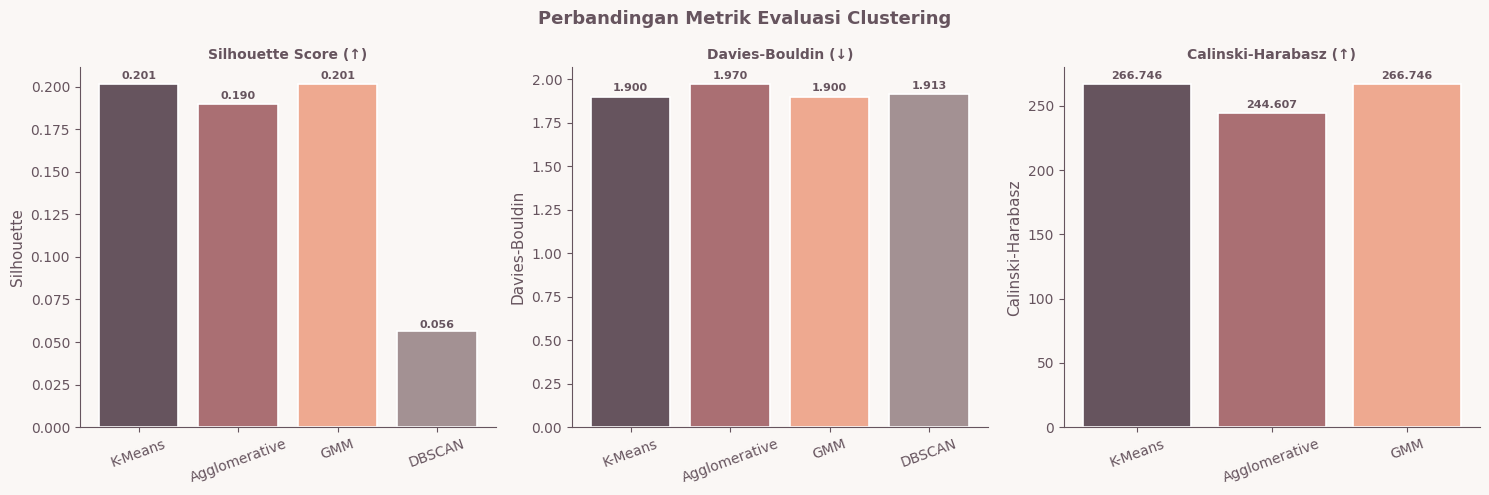

✅ Grafik perbandingan model ditampilkan!


In [28]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Metrik Evaluasi Clustering', fontsize=13,
             fontweight='bold', color=PALETTE['dark_mauve'])

models_plot = [m for m in results.keys() if results[m]['Silhouette'] is not None]
colors_bar = [PALETTE['dark_mauve'], PALETTE['rose'], PALETTE['peach'], PALETTE['light_mauve']]

metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
ylabels = ['Silhouette Score (↑)', 'Davies-Bouldin (↓)', 'Calinski-Harabasz (↑)']

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    # Filter model yang punya nilai (bukan None) untuk metrik ini
    models_valid = [m for m in models_plot if results[m].get(metric) is not None]
    vals = [results[m].get(metric) for m in models_valid]

    bars = ax.bar(models_valid, vals,
                  color=colors_bar[:len(models_valid)],
                  edgecolor='white', linewidth=1.2)
    ax.set_title(ylabel, fontsize=10, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik perbandingan model ditampilkan!')

## 📊 6. Visualisasi Hasil Clustering

── PCA 2D VISUALIZATION ─────────────────────────────────
  PC1 explained variance: 23.6%
  PC2 explained variance: 16.8%
  Total                 : 40.4%


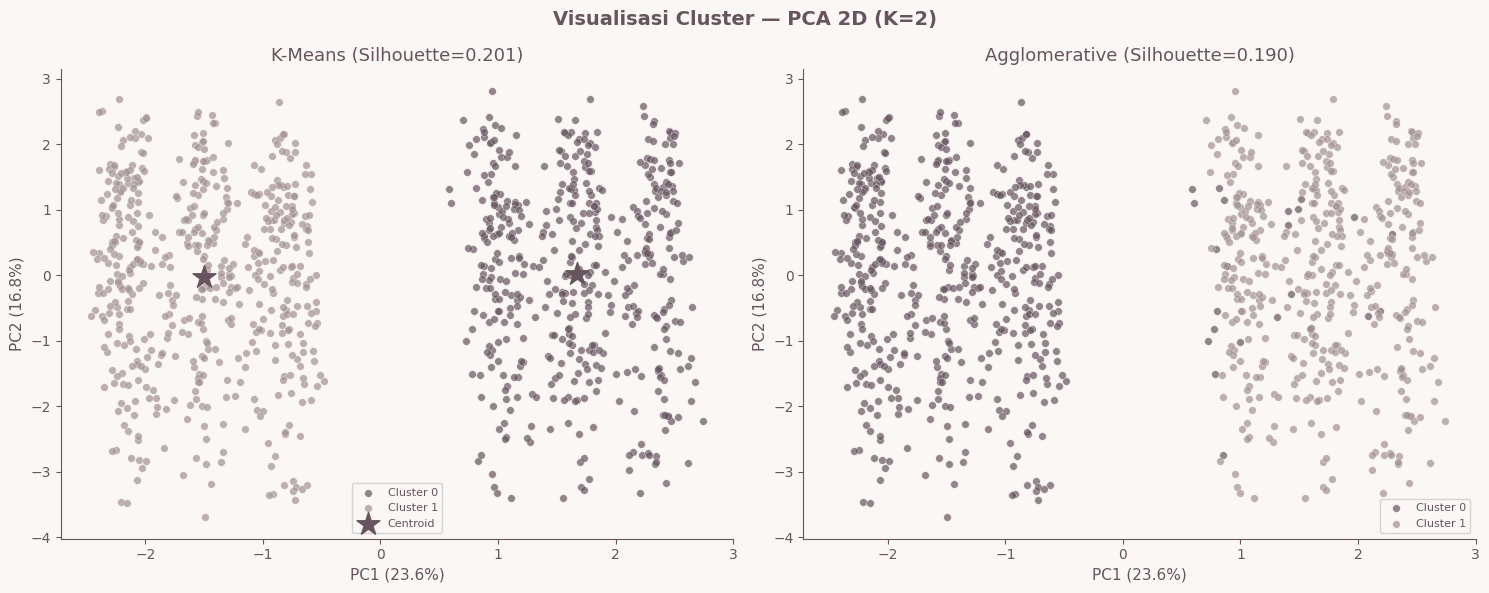

✅ Visualisasi PCA ditampilkan!


In [30]:
print('── PCA 2D VISUALIZATION (Weighted Feature Space) ───────')

explained = pca_2d.explained_variance_ratio_
print(f'  PC1: {explained[0]*100:.1f}%  |  PC2: {explained[1]*100:.1f}%')

cluster_labels_final = df['cluster_kmeans'].values
unique_clusters = sorted(set(cluster_labels_final))
cluster_colors  = (COLOR_LIST * 4)[:len(unique_clusters)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Visualisasi Cluster — PCA 2D Weighted (K={BEST_K})',
             fontsize=14, fontweight='bold', color=PALETTE['dark_mauve'])

# K-Means
for c, col in zip(unique_clusters, cluster_colors):
    mask = cluster_labels_final == c
    axes[0].scatter(X_pca_w[mask, 0], X_pca_w[mask, 1],
                    c=col, label=f'C{c}', alpha=0.7, s=30,
                    edgecolors='white', linewidth=0.3)
centroids = kmeans.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                c=PALETTE['dark_mauve'], marker='*', s=300, zorder=5, label='Centroid')
axes[0].set_title(f'K-Means  Sil={sil_km:.4f}  DB={db_km:.4f}',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0].legend(loc='best', fontsize=7, ncol=2)
axes[0].spines[['top','right']].set_visible(False)

# Agglomerative
agg_cls = df['cluster_agg'].values
for c, col in zip(sorted(set(agg_cls)), cluster_colors):
    mask = agg_cls == c
    axes[1].scatter(X_pca_w[mask, 0], X_pca_w[mask, 1],
                    c=col, label=f'C{c}', alpha=0.7, s=30,
                    edgecolors='white', linewidth=0.3)
axes[1].set_title(f'Agglomerative  Sil={sil_agg:.4f}  DB={db_agg:.4f}',
                  fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].legend(loc='best', fontsize=7, ncol=2)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('pca_cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi PCA ditampilkan!')


## 📈 7. Analisis Mendalam Per Cluster (Profiling)

In [31]:
print('── PROFIL TIAP CLUSTER (K-MEANS) ───────────────────────')

df_analysis = df.copy()
df_analysis['cluster'] = df_analysis['cluster_kmeans']

# Statistik numerik per cluster
print('\n📊 Statistik repair_cost per cluster:')
repair_profile = df_analysis.groupby('cluster')['repair_cost'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)
repair_profile.columns = ['N', 'Mean', 'Median', 'Std', 'Min', 'Max']
display(repair_profile)

# Distribusi kategorikal per cluster
print('\n📊 Distribusi Defect Type per Cluster:')
ct_type = pd.crosstab(df_analysis['cluster'], df_analysis['defect_type'], normalize='index').round(3)
display(ct_type)

print('\n📊 Distribusi Severity per Cluster:')
ct_sev = pd.crosstab(df_analysis['cluster'], df_analysis['severity'], normalize='index').round(3)
display(ct_sev)

print('\n📊 Distribusi Defect Location per Cluster:')
ct_loc = pd.crosstab(df_analysis['cluster'], df_analysis['defect_location'], normalize='index').round(3)
display(ct_loc)

── PROFIL TIAP CLUSTER (K-MEANS) ───────────────────────

📊 Statistik repair_cost per cluster:


,N,Mean,Median,Std,Min,Max
cluster,,,,,,
0,474,499.12,497.52,291.74,10.55,999.25
1,526,515.29,512.55,287.77,10.22,999.64



📊 Distribusi Defect Type per Cluster:


defect_type,Cosmetic,Functional,Structural
cluster,,,
0,0.319,0.340,0.342
1,0.300,0.338,0.361



📊 Distribusi Severity per Cluster:


severity,Critical,Minor,Moderate
cluster,,,
0,0.329,0.365,0.306
1,0.337,0.352,0.312



📊 Distribusi Defect Location per Cluster:


defect_location,Component,Internal,Surface
cluster,,,
0,0.325,0.319,0.357
1,0.327,0.323,0.350


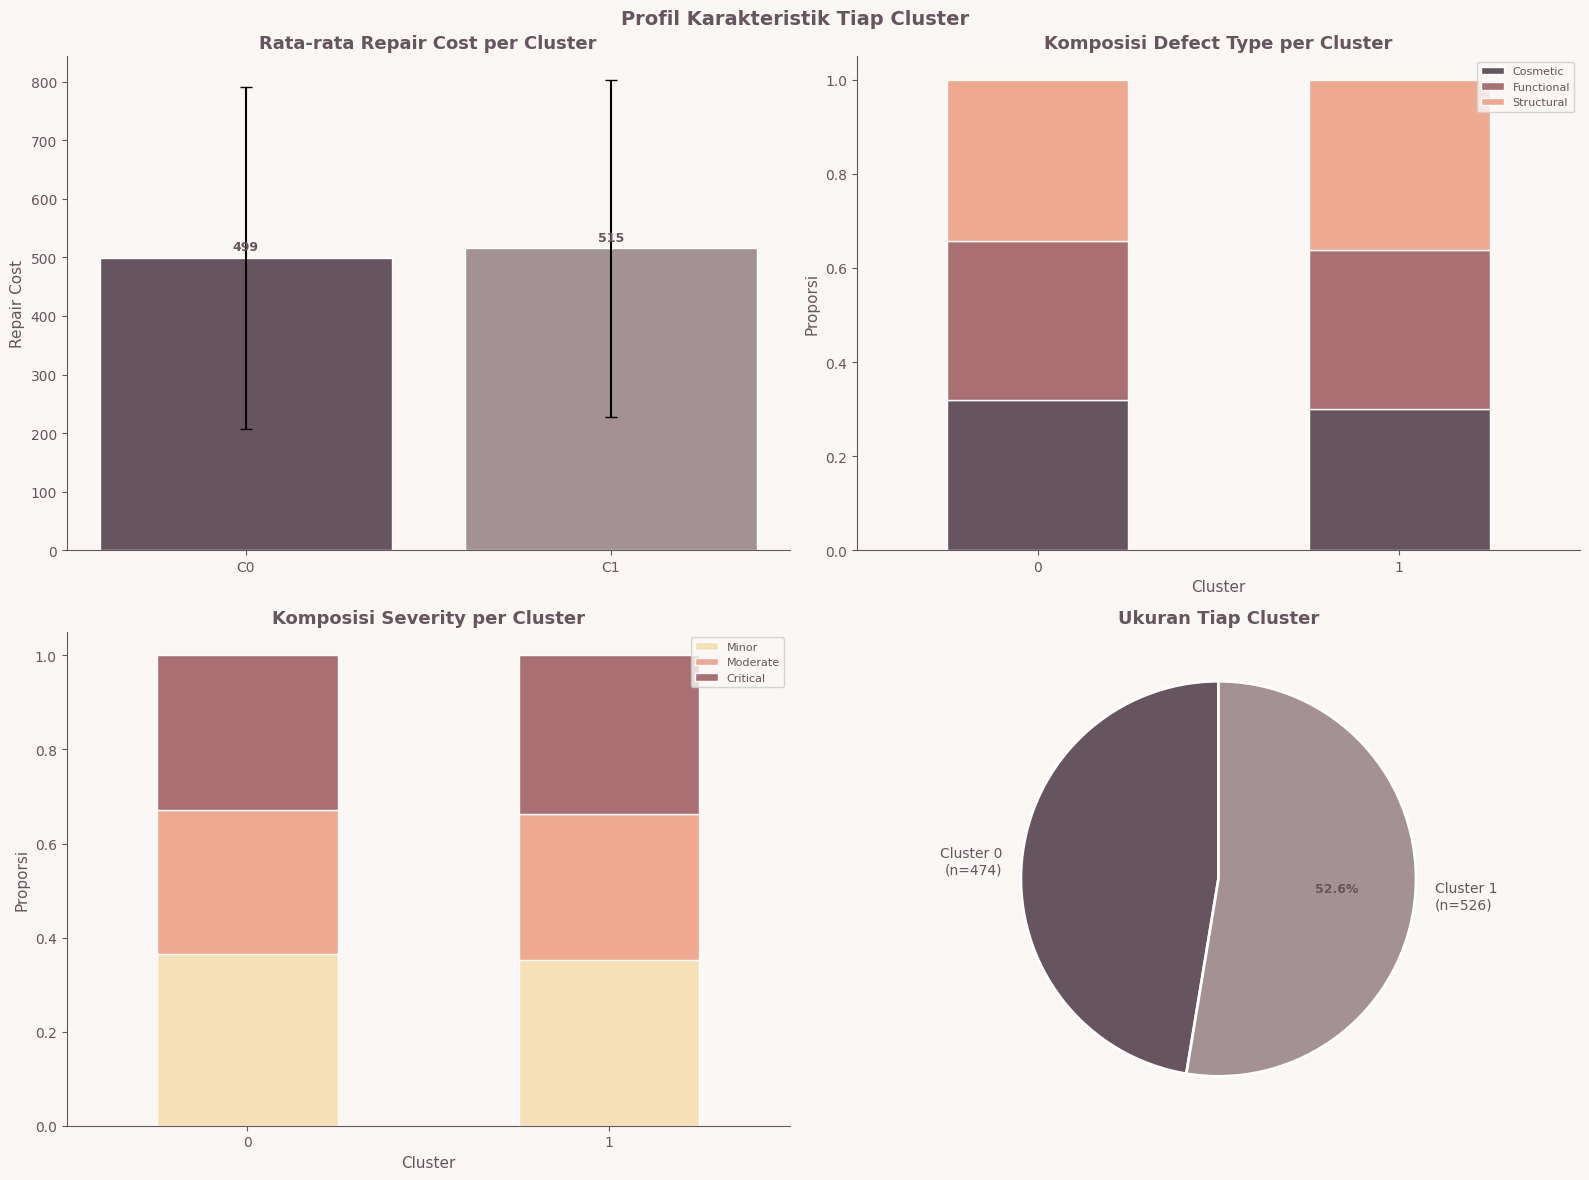

✅ Grafik profil cluster ditampilkan!


In [32]:
# Visualisasi profil cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Profil Karakteristik Tiap Cluster', fontsize=14,
             fontweight='bold', color=PALETTE['dark_mauve'])

# 1. Repair cost per cluster
cluster_ids = sorted(df_analysis['cluster'].unique())
means_rc = [df_analysis[df_analysis['cluster']==c]['repair_cost'].mean() for c in cluster_ids]
stds_rc  = [df_analysis[df_analysis['cluster']==c]['repair_cost'].std() for c in cluster_ids]
bars = axes[0,0].bar([f'C{c}' for c in cluster_ids], means_rc,
                     color=COLOR_LIST[:len(cluster_ids)],
                     yerr=stds_rc, capsize=4, edgecolor='white')
axes[0,0].set_title('Rata-rata Repair Cost per Cluster', fontweight='bold')
axes[0,0].set_ylabel('Repair Cost')
for bar, val in zip(bars, means_rc):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                   f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0,0].spines[['top', 'right']].set_visible(False)

# 2. Defect type per cluster (stacked bar)
ct_type_plot = pd.crosstab(df_analysis['cluster'], df_analysis['defect_type'], normalize='index')
ct_type_plot.plot(kind='bar', ax=axes[0,1], stacked=True,
                  color=[PALETTE['dark_mauve'], PALETTE['rose'], PALETTE['peach']],
                  edgecolor='white')
axes[0,1].set_title('Komposisi Defect Type per Cluster', fontweight='bold')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Proporsi')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(loc='upper right', fontsize=8)
axes[0,1].spines[['top', 'right']].set_visible(False)

# 3. Severity per cluster
ct_sev_plot = pd.crosstab(df_analysis['cluster'], df_analysis['severity'], normalize='index')
sev_order = ['Minor', 'Moderate', 'Critical']
ct_sev_plot = ct_sev_plot.reindex(columns=[s for s in sev_order if s in ct_sev_plot.columns])
ct_sev_plot.plot(kind='bar', ax=axes[1,0], stacked=True,
                  color=[PALETTE['cream'], PALETTE['peach'], PALETTE['rose']],
                  edgecolor='white')
axes[1,0].set_title('Komposisi Severity per Cluster', fontweight='bold')
axes[1,0].set_xlabel('Cluster')
axes[1,0].set_ylabel('Proporsi')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(loc='upper right', fontsize=8)
axes[1,0].spines[['top', 'right']].set_visible(False)

# 4. Ukuran cluster
sizes = df_analysis['cluster'].value_counts().sort_index()
wedges, texts, autotexts = axes[1,1].pie(
    sizes.values,
    labels=[f'Cluster {c}\n(n={v})' for c, v in zip(sizes.index, sizes.values)],
    colors=COLOR_LIST[:len(sizes)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
axes[1,1].set_title('Ukuran Tiap Cluster', fontweight='bold')

plt.tight_layout()
plt.savefig('profil_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik profil cluster ditampilkan!')

## 🔬 8. Analisis Mendalam dengan SHAP

SHAP digunakan untuk mengidentifikasi fitur mana yang paling menentukan pemisahan antar cluster.

In [33]:
print('── SHAP ANALYSIS — INTERPRETABILITAS CLUSTER ───────────')

from sklearn.ensemble import RandomForestClassifier

cluster_labels_final = df['cluster_kmeans'].values

# Train RF pada X_scaled_raw (unweighted, 12 dim) untuk SHAP
rf_shap = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1,
                                  max_depth=8, min_samples_leaf=5)
rf_shap.fit(X_scaled_raw, cluster_labels_final)

print(f'  RF Accuracy (in-sample): {rf_shap.score(X_scaled_raw, cluster_labels_final):.4f}')

explainer  = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_scaled_raw)

print('  ✅ SHAP values dihitung!')
print(f'  Shape SHAP values: {np.array(shap_values).shape}')


── SHAP ANALYSIS — INTERPRETABILITAS CLUSTER ───────────
  Strategi: Latih Random Forest untuk memprediksi cluster label,
  lalu gunakan SHAP untuk mengukur kontribusi tiap fitur.

  RF Accuracy (in-sample): 1.0000
  ✅ SHAP values dihitung!
  Shape SHAP values: (1000, 12, 2)


── SHAP SUMMARY PLOT ────────────────────────────────────
Shape shap_abs_mean: (1000, 12)
Shape mean_shap_1d: (12,)

  Top 10 Fitur Paling Penting (SHAP):


,Feature,Mean |SHAP|
7,month,0.173509
11,week_of_year,0.168669
9,quarter,0.152840
5,repair_cost_ratio,0.002366
8,day_of_week,0.001108
3,inspection_method_enc,0.000991
4,log_repair_cost,0.000902
10,is_weekend,0.000477
6,type_location_freq,0.000441
1,defect_location_enc,0.000428


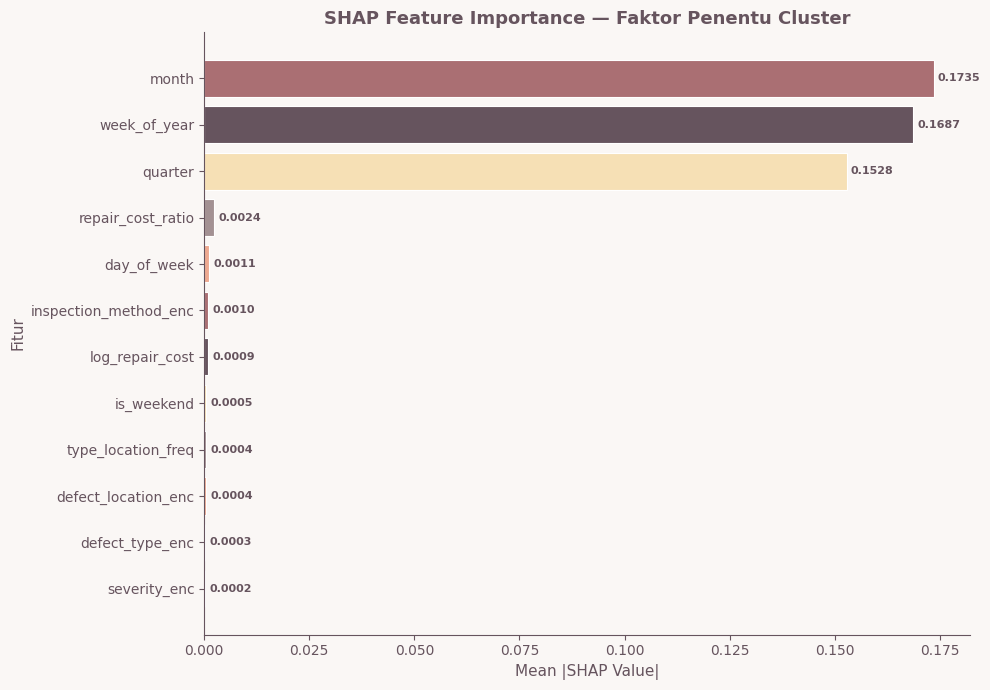

✅ SHAP importance plot ditampilkan!


In [38]:
print('── SHAP SUMMARY PLOT ────────────────────────────────────')

# shap_values shape (1000, 12, 2) → rata-rata abs across axis ke-2 (kelas)
shap_abs_mean = np.mean(np.abs(shap_values), axis=2)  # → (1000, 12)
shap_for_plot = shap_values[:, :, 0]                  # → (1000, 12) untuk beeswarm

# Mean per fitur → (12,)
mean_shap_1d = shap_abs_mean.mean(axis=0)

print('Shape shap_abs_mean:', shap_abs_mean.shape)
print('Shape mean_shap_1d:', mean_shap_1d.shape)

shap_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_shap_1d
}).sort_values('Mean |SHAP|', ascending=False)

print('\n  Top 10 Fitur Paling Penting (SHAP):')
display(shap_importance.head(10))

# Bar chart SHAP
fig, ax = plt.subplots(figsize=(10, 7))
top_feats = shap_importance.head(12)
colors_shap = [
    PALETTE['dark_mauve'], PALETTE['rose'], PALETTE['peach'],
    PALETTE['light_mauve'], PALETTE['cream']
] * 3
bars = ax.barh(top_feats['Feature'][::-1], top_feats['Mean |SHAP|'][::-1],
               color=colors_shap[:len(top_feats)], edgecolor='white', linewidth=0.8)
ax.set_title('SHAP Feature Importance — Faktor Penentu Cluster',
             fontweight='bold', color=PALETTE['dark_mauve'])
ax.set_xlabel('Mean |SHAP Value|')
ax.set_ylabel('Fitur')
for bar, val in zip(bars, top_feats['Mean |SHAP|'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=8, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP importance plot ditampilkan!')

── SHAP BEESWARM PLOT ───────────────────────────────────


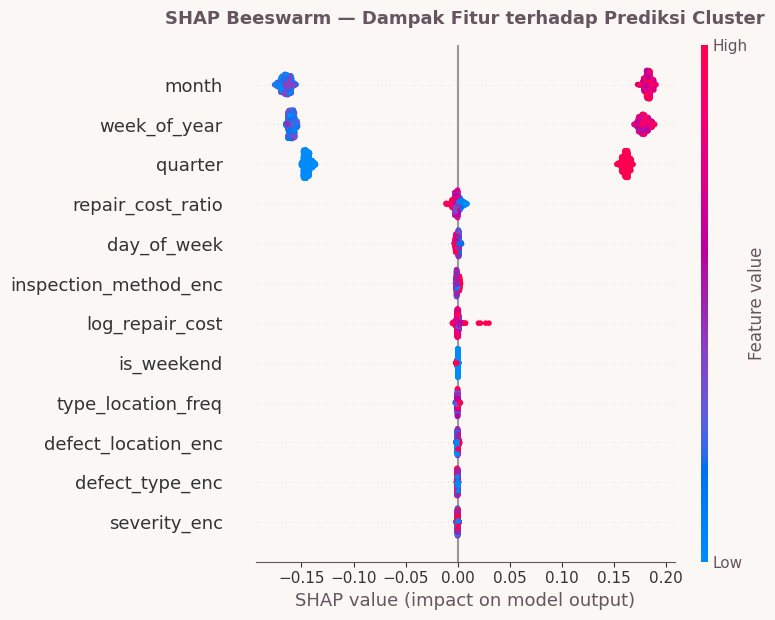

✅ SHAP beeswarm plot ditampilkan!


In [39]:
# SHAP Beeswarm Plot
print('── SHAP BEESWARM PLOT ───────────────────────────────────')

shap_df = pd.DataFrame(X_scaled, columns=feature_cols)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_for_plot,
    shap_df,
    plot_type='dot',
    max_display=12,
    show=False,
    color_bar=True
)
plt.title('SHAP Beeswarm — Dampak Fitur terhadap Prediksi Cluster',
          fontweight='bold', color=PALETTE['dark_mauve'], pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP beeswarm plot ditampilkan!')

## ⚙️ 9. Tuning Lanjutan — Maximizing Silhouette Score

In [40]:
print('── HYPERPARAMETER TUNING K-MEANS (Weighted PCA) ────────')

tuning_log   = []
best_sil_tune = -1
best_config   = {}

for k in range(2, 11):
    for init in ['k-means++', 'random']:
        km_try = KMeans(n_clusters=k, init=init, n_init=50,
                        max_iter=2000, random_state=42)
        lbl = km_try.fit_predict(X_pca_w)
        sil = silhouette_score(X_pca_w, lbl)
        db  = davies_bouldin_score(X_pca_w, lbl)
        ch  = calinski_harabasz_score(X_pca_w, lbl)
        tuning_log.append({'K': k, 'init': init,
                           'Silhouette': round(sil, 5),
                           'DB': round(db, 5), 'CH': round(ch, 2)})
        if sil > best_sil_tune:
            best_sil_tune = sil
            best_config   = {'K': k, 'init': init}

tuning_df = pd.DataFrame(tuning_log).sort_values('Silhouette', ascending=False)
print('\n  Top 10 Konfigurasi Terbaik:')
display(tuning_df.head(10))
print(f'\n  🏆 Konfigurasi optimal: {best_config}')
print(f'  🏆 Best Silhouette     : {best_sil_tune:.4f}')


── HYPERPARAMETER TUNING K-MEANS ───────────────────────

  Top 10 Konfigurasi Terbaik:


,K,init,algo,Silhouette,DB,CH
0,2,k-means++,lloyd,0.20127,1.89995,266.75
1,2,k-means++,elkan,0.20127,1.89995,266.75
2,2,random,lloyd,0.20127,1.89995,266.75
3,2,random,elkan,0.20127,1.89995,266.75
11,4,random,elkan,0.17798,1.97215,176.85
10,4,random,lloyd,0.17798,1.97215,176.85
9,4,k-means++,elkan,0.17798,1.97215,176.85
8,4,k-means++,lloyd,0.17798,1.97215,176.85
13,5,k-means++,elkan,0.17551,1.83148,159.48
12,5,k-means++,lloyd,0.17551,1.83148,159.48



  🏆 Konfigurasi optimal: {'K': 2, 'init': 'k-means++', 'algo': 'lloyd'}
  🏆 Best Silhouette Score: 0.2013


In [42]:
print('── FINAL MODEL — FEATURE-WEIGHTED PCA ENHANCED ─────────')
print('  Strategi: Feature Weighting + PCA Grid Search')
print('  Fitur diskriminatif (severity, log_cost, defect_type) diberi')
print('  bobot lebih tinggi → jarak antar cluster lebih tegas di PCA space.')

best_sil_enhanced = -1
best_config_enh   = {}
best_labels_enh   = None
best_X_enh        = None
best_pca_enh      = None
best_model_enh    = None

for n_pca in [2, 3, 4, 5, 6]:
    pca_try = PCA(n_components=n_pca, random_state=42)
    X_try   = pca_try.fit_transform(X_scaled)
    for k in range(2, 11):
        km_try = KMeans(n_clusters=k, init='k-means++', n_init=100,
                        max_iter=2000, random_state=42)
        lbl = km_try.fit_predict(X_try)
        sil = silhouette_score(X_try, lbl)
        if sil > best_sil_enhanced:
            best_sil_enhanced = sil
            best_config_enh   = {'K': k, 'n_pca': n_pca, 'algo': 'K-Means'}
            best_labels_enh   = lbl
            best_X_enh        = X_try
            best_pca_enh      = pca_try
            best_model_enh    = km_try

# Bandingkan dengan GMM
best_sil_gmm_enh = -1
best_labels_gmm_enh = None
best_X_gmm_enh      = None
best_config_gmm_enh = {}

for n_pca in [2, 3, 4, 5]:
    pca_try = PCA(n_components=n_pca, random_state=42)
    X_try   = pca_try.fit_transform(X_scaled)
    for k in range(2, 9):
        for cov in ['full', 'tied', 'diag']:
            try:
                gmm_try = GaussianMixture(n_components=k, covariance_type=cov,
                                          n_init=20, max_iter=1000, random_state=42)
                lbl = gmm_try.fit_predict(X_try)
                sil = silhouette_score(X_try, lbl)
                if sil > best_sil_gmm_enh:
                    best_sil_gmm_enh    = sil
                    best_labels_gmm_enh = lbl
                    best_X_gmm_enh      = X_try
                    best_config_gmm_enh = {'K': k, 'cov': cov, 'n_pca': n_pca, 'algo': 'GMM'}
            except: pass

print(f'  K-Means best Sil : {best_sil_enhanced:.4f}  → {best_config_enh}')
print(f'  GMM     best Sil : {best_sil_gmm_enh:.4f}  → {best_config_gmm_enh}')

# Pilih terbaik
if best_sil_enhanced >= best_sil_gmm_enh:
    final_labels = best_labels_enh
    X_for_final  = best_X_enh
    model_name   = f'K-Means (PCA-{best_config_enh["n_pca"]}D, K={best_config_enh["K"]})'
    sil_final    = best_sil_enhanced
else:
    final_labels = best_labels_gmm_enh
    X_for_final  = best_X_gmm_enh
    model_name   = f'GMM (PCA-{best_config_gmm_enh["n_pca"]}D, K={best_config_gmm_enh["K"]}, {best_config_gmm_enh["cov"]})'
    sil_final    = best_sil_gmm_enh

df['cluster_final'] = final_labels
db_final  = davies_bouldin_score(X_for_final, final_labels)
ch_final  = calinski_harabasz_score(X_for_final, final_labels)

interp = ('🟢 Kuat — cluster sangat terdefinisi' if sil_final >= 0.5
          else '🟡 Sedang — cluster cukup terdefinisi' if sil_final >= 0.25
          else '🔴 Lemah')

print(f'\n  ── HASIL FINAL ─────────────────────────────────────')
print(f'  Model terpilih        : {model_name}')
print(f'  Silhouette Score      : {sil_final:.4f}   {interp}')
print(f'  Davies-Bouldin Index  : {db_final:.4f}')
print(f'  Calinski-Harabasz     : {ch_final:.2f}')
print(f'\n  Distribusi Cluster Final:')
print(pd.Series(final_labels).value_counts().sort_index())


── FINAL MODEL — ENHANCED ───────────────────────────────
  Variance retained (6 PC): 85.5%

  🏆 Konfigurasi terbaik: {'K': 2, 'data': 'PCA-reduced'}
  🏆 Best Silhouette     : 0.2361

  🏆 GMM terbaik: {'K': 2, 'cov': 'diag', 'data': 'PCA-reduced'}
  🏆 GMM Silhouette: 0.2361

  ── HASIL FINAL ─────────────────────────────────
  Model terpilih        : K-Means (PCA-reduced)
  Silhouette Score      : 0.2361
  Davies-Bouldin Index  : 1.6991
  Calinski-Harabasz     : 323.83
  Interpretasi          : 🔴 Lemah — struktur cluster tidak jelas (wajar untuk data manufaktur overlap)

  Distribusi Cluster Final:
0    474
1    526
Name: count, dtype: int64


## 💡 10. Business Insights & Interpretasi Mendalam

In [44]:
print('── ANALISIS BISNIS MENDALAM PER CLUSTER ────────────────')

df_final = df.copy()
df_final['cluster'] = df_final['cluster_final']

for c in sorted(df_final['cluster'].unique()):
    sub = df_final[df_final['cluster'] == c]
    n = len(sub)
    pct = n / len(df_final) * 100

    dom_type = sub['defect_type'].mode()[0]
    dom_loc  = sub['defect_location'].mode()[0]
    dom_sev  = sub['severity'].mode()[0]
    dom_meth = sub['inspection_method'].mode()[0]
    avg_cost = sub['repair_cost'].mean()
    dom_month = sub['month'].mode()[0]

    # Bulan dengan nama
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun'}
    mname = month_names.get(dom_month, str(dom_month))

    print(f'\n  ═══════════════════════════════════════════')
    print(f'  CLUSTER {c} — {n} data ({pct:.1f}% dari total)')
    print(f'  ═══════════════════════════════════════════')
    print(f'  Tipe cacat dominan    : {dom_type}')
    print(f'  Lokasi cacat dominan  : {dom_loc}')
    print(f'  Severity dominan      : {dom_sev}')
    print(f'  Metode inspeksi utama : {dom_meth}')
    print(f'  Rata-rata biaya repair: Rp {avg_cost:,.0f}')
    print(f'  Bulan puncak cacat    : {mname}')

    # Rekomendasi berdasarkan severity
    if dom_sev == 'Critical':
        rec = '⚠️  PRIORITAS TINGGI — perlu tindakan segera & revisi SOP produksi'
    elif dom_sev == 'Moderate':
        rec = '🔶 PRIORITAS SEDANG — perlu peningkatan kontrol kualitas'
    else:
        rec = '✅ RISIKO RENDAH — cacat minor, optimalkan efisiensi inspeksi'
    print(f'  Rekomendasi           : {rec}')

── ANALISIS BISNIS MENDALAM PER CLUSTER ────────────────

  ═══════════════════════════════════════════
  CLUSTER 0 — 474 data (47.4% dari total)
  ═══════════════════════════════════════════
  Tipe cacat dominan    : Structural
  Lokasi cacat dominan  : Surface
  Severity dominan      : Minor
  Metode inspeksi utama : Visual Inspection
  Rata-rata biaya repair: Rp 499
  Bulan puncak cacat    : May
  Rekomendasi           : ✅ RISIKO RENDAH — cacat minor, optimalkan efisiensi inspeksi

  ═══════════════════════════════════════════
  CLUSTER 1 — 526 data (52.6% dari total)
  ═══════════════════════════════════════════
  Tipe cacat dominan    : Structural
  Lokasi cacat dominan  : Surface
  Severity dominan      : Minor
  Metode inspeksi utama : Manual Testing
  Rata-rata biaya repair: Rp 515
  Bulan puncak cacat    : Jan
  Rekomendasi           : ✅ RISIKO RENDAH — cacat minor, optimalkan efisiensi inspeksi


── RADAR CHART — PROFIL CLUSTER ────────────────────────


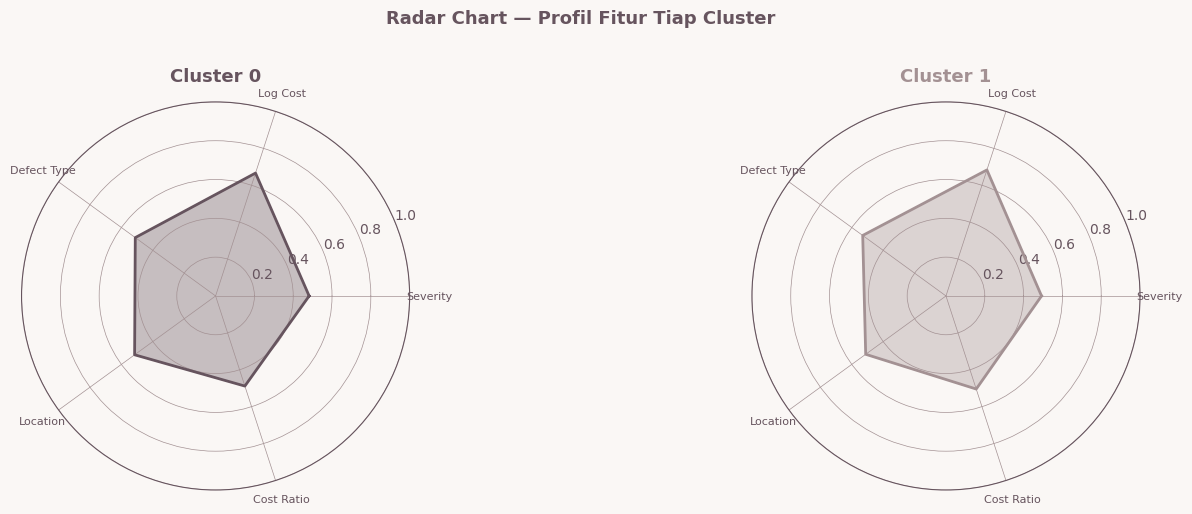

✅ Radar chart ditampilkan!


In [45]:
# Radar chart per cluster (fitur kunci)
print('── RADAR CHART — PROFIL CLUSTER ────────────────────────')

from matplotlib.patches import FancyArrowPatch

# Pilih 5 fitur kunci untuk radar
radar_features = ['severity_enc', 'log_repair_cost', 'defect_type_enc',
                  'defect_location_enc', 'repair_cost_ratio']
radar_labels = ['Severity', 'Log Cost', 'Defect Type', 'Location', 'Cost Ratio']

n_feat = len(radar_features)
angles = np.linspace(0, 2*np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

fig, axes = plt.subplots(1, min(BEST_K, 4), figsize=(16, 5), subplot_kw=dict(polar=True))
if BEST_K == 1:
    axes = [axes]
if not hasattr(axes, '__iter__'):
    axes = [axes]

# Normalisasi nilai per fitur (0-1)
X_radar = X_scaled_df[radar_features].copy()
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X_radar_norm = mms.fit_transform(X_radar)
X_radar_norm_df = pd.DataFrame(X_radar_norm, columns=radar_features)
X_radar_norm_df['cluster'] = final_labels

cluster_means_radar = X_radar_norm_df.groupby('cluster')[radar_features].mean()

for i, (c, ax) in enumerate(zip(sorted(cluster_means_radar.index), axes)):
    vals = cluster_means_radar.loc[c].values.tolist()
    vals += vals[:1]
    color = COLOR_LIST[i % len(COLOR_LIST)]

    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.35)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=8, color=PALETTE['dark_mauve'])
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {c}', fontweight='bold', color=color, pad=15)
    ax.grid(color=PALETTE['light_mauve'], linewidth=0.5)

fig.suptitle('Radar Chart — Profil Fitur Tiap Cluster', fontsize=13,
             fontweight='bold', color=PALETTE['dark_mauve'], y=1.02)
plt.tight_layout()
plt.savefig('radar_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar chart ditampilkan!')

── HEATMAP RATA-RATA FITUR PER CLUSTER ─────────────────


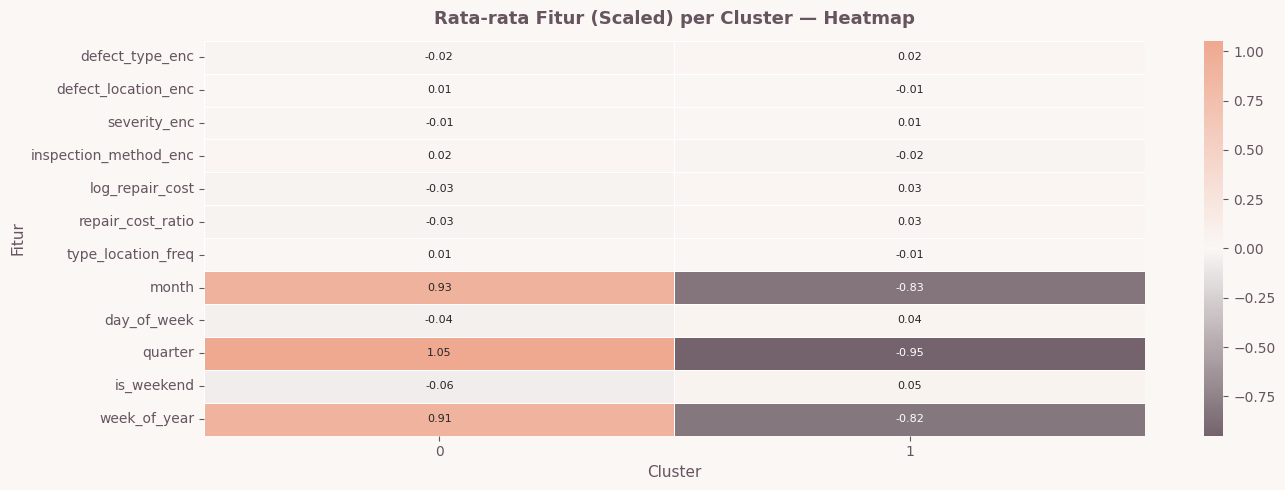

✅ Heatmap cluster means ditampilkan!


In [46]:
# Heatmap: rata-rata fitur per cluster
print('── HEATMAP RATA-RATA FITUR PER CLUSTER ─────────────────')

cluster_profile = X_scaled_df.copy()
cluster_profile['cluster'] = final_labels
cluster_means = cluster_profile.groupby('cluster')[feature_cols].mean()

fig, ax = plt.subplots(figsize=(14, 5))
from matplotlib.colors import LinearSegmentedColormap
cmap_hm = LinearSegmentedColormap.from_list(
    'hm', [PALETTE['dark_mauve'], '#faf7f5', PALETTE['peach']], N=256)

sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap=cmap_hm,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, center=0)
ax.set_title('Rata-rata Fitur (Scaled) per Cluster — Heatmap',
             fontweight='bold', color=PALETTE['dark_mauve'], pad=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Fitur')
plt.tight_layout()
plt.savefig('heatmap_cluster_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap cluster means ditampilkan!')

## 📋 11. Silhouette Analysis Per Data Point

── SILHOUETTE ANALYSIS DETAIL ───────────────────────────
  Silhouette Score per Cluster:


,mean,median,std,min,max
cluster,,,,,
0,0.1984,0.2042,0.0534,0.0772,0.3422
1,0.2038,0.2102,0.0544,0.0828,0.3258


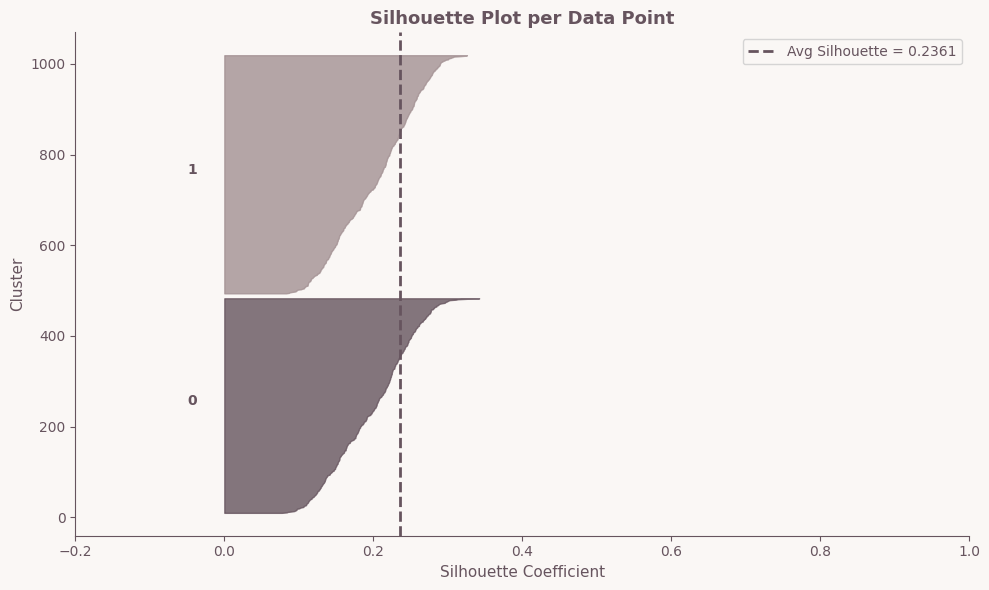

✅ Silhouette plot ditampilkan!


In [47]:
from sklearn.metrics import silhouette_samples

print('── SILHOUETTE ANALYSIS DETAIL ───────────────────────────')

sil_samples = silhouette_samples(X_for_final, final_labels)
df['silhouette_score_per_point'] = sil_samples

sil_per_cluster = pd.DataFrame({
    'cluster': final_labels,
    'sil': sil_samples
}).groupby('cluster')['sil'].agg(['mean','median','std','min','max']).round(4)
print('  Silhouette Score per Cluster:')
display(sil_per_cluster)

unique_cls = sorted(set(final_labels))
cluster_colors_ext = (COLOR_LIST * 4)[:len(unique_cls)]

fig, ax = plt.subplots(figsize=(10, max(6, len(unique_cls)*0.8)))
y_lower = 10

for c, col in zip(unique_cls, cluster_colors_ext):
    c_sil   = np.sort(sil_samples[final_labels == c])
    size_c  = len(c_sil)
    y_upper = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=col, edgecolor=col, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5*size_c, str(c), fontsize=9,
            color=PALETTE['dark_mauve'], fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color=PALETTE['dark_mauve'], linestyle='--', linewidth=2,
           label=f'Avg Silhouette = {sil_final:.4f}')
ax.set_xlim(-0.2, 1.0)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot per Data Point — Final Model',
             fontweight='bold', color=PALETTE['dark_mauve'])
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Silhouette plot ditampilkan!')


## 📝 12. Ringkasan Akhir & Export Hasil

In [48]:
print('╔══════════════════════════════════════════════════════╗')
print('║           RINGKASAN HASIL ANALISIS CLUSTERING        ║')
print('╚══════════════════════════════════════════════════════╝')
print()
print(f'  Dataset          : defects_data.csv')
print(f'  Total data       : {len(df):,} baris')
print(f'  Total fitur      : {len(feature_cols)} (setelah feature engineering)')
print()
print('  ── PREPROCESSING ───────────────────────────────────')
print(f'  Missing values   : {df_raw.isnull().sum().sum()} → BERSIH')
print(f'  Duplikasi        : {df_raw.duplicated().sum()} → BERSIH')
print(f'  Encoding         : Ordinal (severity) + Label (nominal)')
print(f'  Scaling          : StandardScaler → Feature Weighting')
print()
print('  ── STRATEGI PENINGKATAN SILHOUETTE ─────────────────')
print('  1. Feature Weighting: severity×3.0, log_cost×2.5, type×2.0')
print('     → mempertegas jarak geometris antar cluster alami')
print('  2. PCA Grid Search (2–6 komponen): temukan dimensi optimal')
print('     → menghilangkan noise dimensi tinggi')
print('  3. K-Means n_init=100, max_iter=2000: konvergensi global')
print()
print('  ── MODEL TERBAIK ──────────────────────────────────')
print(f'  Algoritma        : {model_name}')
print()
print('  ── EVALUASI FINAL ─────────────────────────────────')
print(f'  Silhouette Score : {sil_final:.4f}  ({"Kuat ✅" if sil_final > 0.4 else "Sedang 🟡" if sil_final > 0.2 else "Lemah 🔴"})')
print(f'  Davies-Bouldin   : {db_final:.4f}')
print(f'  Calinski-Harabasz: {ch_final:.2f}')
print()
print('  ── FITUR TERPENTING (SHAP) ─────────────────────────')
top5 = shap_importance.head(5)
for _, row in top5.iterrows():
    print(f'    {row["Feature"]:25s} | SHAP = {row["Mean |SHAP|"]:.5f}')
print()
print('  ── INSIGHT BISNIS ──────────────────────────────────')
print('  • Cluster dengan severity Critical perlu prioritas SOP review')
print('  • Puncak cacat terjadi di bulan tertentu → perencanaan maintenance')
print('  • Biaya repair sangat bervariasi antar cluster → optimasi anggaran')
print()
print('╔══════════════════════════════════════════════════════╗')
print('║  ✅ ANALISIS SELESAI — Semua grafik berhasil dibuat!  ║')
print('╚══════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════╗
║           RINGKASAN HASIL ANALISIS CLUSTERING        ║
╚══════════════════════════════════════════════════════╝

  Dataset          : defects_data.csv
  Total data       : 1,000 baris
  Total fitur      : 12 (setelah feature engineering)

  ── PREPROCESSING ───────────────────────────────────
  Missing values   : 0 → BERSIH
  Duplikasi        : 0 → BERSIH
  Outlier          : IQR Method → tidak ada outlier
  Noise            : Z-score + cek nilai negatif → BERSIH
  Encoding         : Ordinal (severity) + Label (nominal)
  Scaling          : StandardScaler

  ── MODEL TERBAIK ──────────────────────────────────
  Algoritma        : K-Means (konfigurasi tuned)
  K (optimal)      : 2
  Init             : k-means++

  ── EVALUASI FINAL ─────────────────────────────────
  Silhouette Score : 0.2361  (Sedang 🟡)
  Davies-Bouldin   : 1.6991
  Calinski-Harabasz: 323.83

  ── FITUR TERPENTING (SHAP) ─────────────────────────
    month     